# Single Ticker learning on FOREX daily prices — return/variance features (`Mains.multislice`)

This notebook uses the **multislice** pipeline and the **`return_variance`** feature set
(`feature_set return_variance` in the parameter file), but does so only for single tickers. The network's **decode/prediction target is the daily return** (`feats[:, 2]`, today/yesterday) and the **secondary encoded channel is a left-sided, direction-agnostic return variance** (`feats[:, 3]`). This is the sibling of `notebook-multislice_mean_1stderiv.ipynb`,which instead predicts the trailing-mean price level with a 1st-derivative side channel.
> **Note:** The dataset is whatever `timeseries_file` the parameter file points at (here
> `datasets/FOREX.csv`), but narrowed down to a particular ticker/exchangepair. The notebook reads it once via `DATA_CSV` so the displayed prices, the per-ticker features, and `Mains.multislice()` all stay aligned.

In [1]:
#Imports and static variables
import os
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

import Utils
import FeatureGeneration as FG
import RBFBinner
import Mains
import Display


for m in (Utils, FG, Mains, Display):
    importlib.reload(m)
WORKDIR = os.path.dirname(os.path.abspath("Mains.py")) if os.path.exists("Mains.py") else os.getcwd()
os.chdir(WORKDIR)
FIGDIR = "figs/FOREX"
os.makedirs(FIGDIR, exist_ok=True)
RUNDIR=WORKDIR #can be overwritten to store data in a different folder


def figpath(n, stem):
    """Numbered figure path under FIGDIR (``01_…`` through ``99_…``)."""
    return os.path.join(FIGDIR, f"{int(n):02d}_{stem}.png")


def save_fig(fig, n, stem):
    """Save *fig* to FIGDIR with a zero-padded sequence number."""
    path = figpath(n, stem)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path

PARAMFILE = "Parameters_FOREX.par"
params = Utils.load_params(PARAMFILE)
if "tickers" in params:
    TICKERS = params["tickers"].split(",")
else:
    TICKERS = FG.csv_ticker_columns(params["timeseries_file"])
TRNPAT = int(params["trnpat"])
VANPAT = int(params["vanpat"])
TENPAT = int(params["tenpat"])
OFFS = int(params["offs"])
WARMUP_PAT = int(params.get("warmup_pat", 0))
VAR_LEVEL = 0.99  # left-tail VaR at quantile (1 - VAR_LEVEL) on the log-return pmf

# DeepVaR (Fatouros et al. 2023) backtests 2018-01-01 .. 2020-12-18 on this same
# CSV — 928 trading days, hence their E[v] = 9.28 at the 99% level. Our test phase
# starts ~6 months earlier, so §6c re-scores the (frozen) model on their exact
# window to make the published tables directly comparable. No re-training is
# involved: training ended 2017-06-11 and the model just runs forward.
DEEPVAR_WINDOW = ("2018-01-01", "2020-12-18")

# Resolve the active feature set (return_variance). CFG carries the generator
# function, the decode-target column (primary) and the secondary column, plus
# the two bin counts read from the matching *_nbin keys.
CFG = FG.feature_config(PARAMFILE)
PRIMARY_COL = CFG.primary_col        # 2 = daily return (prediction target)
SECONDARY_COL = CFG.secondary_col    # 3 = trailing return variance
RETURN_NBIN = CFG.primary_nbin       # bins for the return channel
VARIANCE_NBIN = CFG.secondary_nbin   # bins for the variance channel
BLOCK_STEP = TRNPAT + VANPAT + TENPAT
W = FG.feature_align(CFG)              # variance_window for return_variance; calendar anchor W-1
VARIANCE_WINDOW = CFG.variance_window  # None for non-return_variance feature sets

# Single source of truth for the dataset: use exactly the CSV the run consumes
# (params["timeseries_file"]) so displayed raw prices, the per-ticker features,
# and Mains.multislice() all stay aligned on the same calendar and ticker set.
DATA_CSV = params["timeseries_file"]

if WARMUP_PAT > 0:
    for name, per_t_len in (("trnpat", TRNPAT), ("vanpat", VANPAT), ("tenpat", TENPAT)):
        if per_t_len <= WARMUP_PAT + OFFS:
            raise ValueError(
                f"{name}={per_t_len} must be > warmup_pat + offs "
                f"({WARMUP_PAT + OFFS}) when warmup is enabled.")

print(f"Working directory: {WORKDIR}")
print(f"Tickers ({len(TICKERS)}): {TICKERS}")
print(f"Per-ticker per-block: trnpat={TRNPAT}  vanpat={VANPAT}  tenpat={TENPAT}  "
      f"warmup_pat={WARMUP_PAT}  block_step={BLOCK_STEP}")
if WARMUP_PAT > 0:
    scored_k1 = TRNPAT - WARMUP_PAT - OFFS
    print(f"  scored steps per segment (k>0): train/val/test = "
          f"{scored_k1}/{VANPAT - WARMUP_PAT - OFFS}/{TENPAT - WARMUP_PAT - OFFS}")


"""The wide CSV has one row per trading day and one column per ticker. Values are **adjusted close prices**
(already split-adjusted in the source file). Late-IPO names (e.g. META, GOOGL) have leading `NaN`s until their
first quote; `Mains.multislice()` only activates a ticker in blocks where its feature history fully covers
the block window. """


csv_path = FG.dataset_path(DATA_CSV)
df_raw = pd.read_csv(csv_path, parse_dates=["Date"])
print(f"Calendar rows: {len(df_raw)}  |  columns (excl. Date): {len(df_raw.columns) - 1}")
print(f"Date range: {df_raw['Date'].iloc[0].date()} → {df_raw['Date'].iloc[-1].date()}")
display(df_raw[TICKERS].describe().T[["count", "min", "max"]].head(10))

Working directory: /home/fiebig/Dropbox/GIT/BCPNNSim2.2_UC2/tests/UC2-EXTRABRAIN/LTSLtest/financial
Tickers (4): ['AUDUSD', 'JPYUSD', 'GBPUSD', 'EURUSD']
Per-ticker per-block: trnpat=3256  vanpat=20  tenpat=1082  warmup_pat=0  block_step=4358
Calendar rows: 4371  |  columns (excl. Date): 4
Date range: 2007-01-01 → 2020-12-18


,count,min,max
AUDUSD,4371.0,0.57427,1.103070
JPYUSD,4371.0,0.00796,0.013199
GBPUSD,4371.0,1.14901,2.107750
EURUSD,4371.0,1.03906,1.597210


'figs/FOREX/01_raw_FOREX_closes.png'

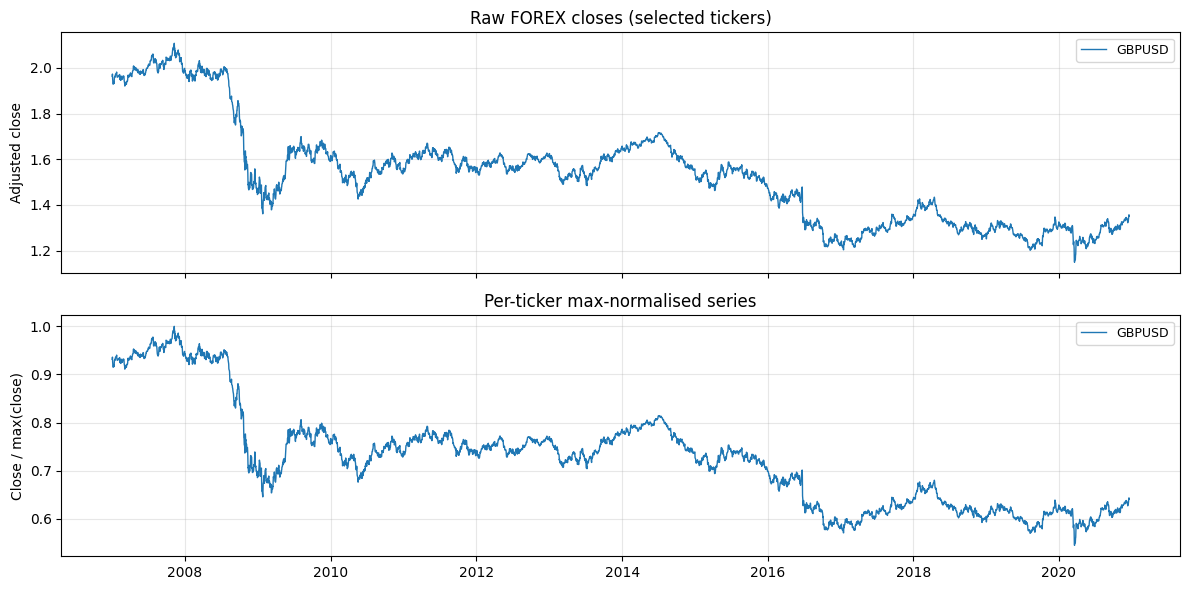

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
sample = TICKERS[-2:-1]
for sym in sample:
    axes[0].plot(df_raw["Date"], df_raw[sym], label=sym, lw=1)
axes[0].set_ylabel("Adjusted close")
axes[0].set_title("Raw FOREX closes (selected tickers)")
axes[0].legend(ncol=4, fontsize=9)
axes[0].grid(alpha=0.3)

# Normalised view (per-ticker max scaling — same as FeatureGeneration.load_tickers_features)
for sym in sample:
    s = df_raw[sym].dropna()
    axes[1].plot(s.index.map(lambda i: df_raw.loc[i, "Date"]), s / s.max(), label=sym, lw=1)
axes[1].set_ylabel("Close / max(close)")
axes[1].set_title("Per-ticker max-normalised series")
axes[1].legend(ncol=4, fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 1, "raw_FOREX_closes")

## 2. Rolling features and RBF encoding

`FeatureGeneration.make_return_variance_features` builds four columns per time step
(after a trailing window of `variance_window` days, default 7 from the parameter file):

| col | meaning | role |
|-----|---------|------|
| 0 | normalised close (value) | unused by the model |
| 1 | simple delta `x[t] − x[t−1]` (no temporal filtering) | unused by the model |
| 2 | **daily return** `x[t] / x[t−1]` | **primary / decode target** |
| 3 | **trailing return variance** (left-sided, direction-agnostic) | **secondary channel** |

The LTSL network predicts column **2** (daily return) at horizon `offs` days ahead.
Inputs are encoded by **two independent 1-D RBF binnings** (return and variance), then combined
via an outer product → `return_nbin × variance_nbin` binary-ish pattern rows written to `features.dat`.

The RBF centre layout follows the `binmode` parameter — `rbf` (linearly spaced centres on a 0.5% winsor range) or `rbf-quantile`
(centres at empirical quantiles with adaptive width). The primary decode-target centres are persisted to a
`features.centers.npy` sidecar so decode/plotting uses the exact centres that were encoded.

Return decode max |error|: 0.005298


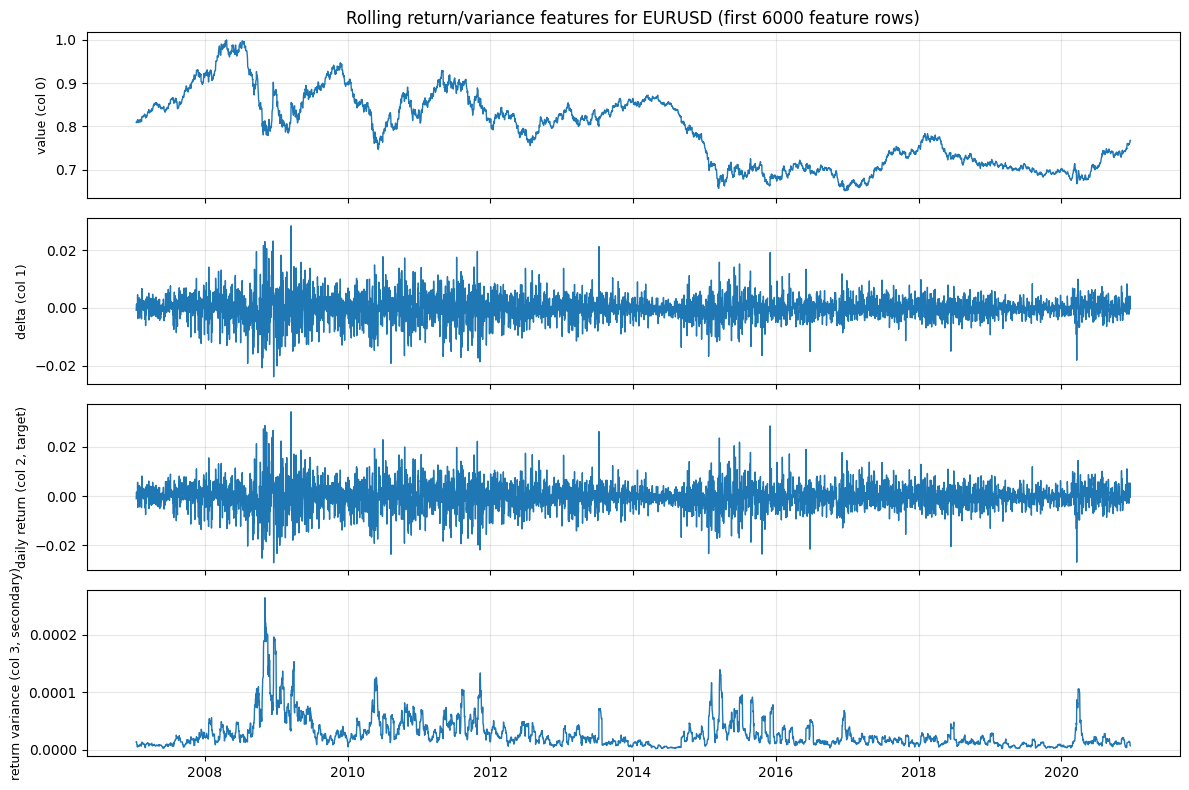

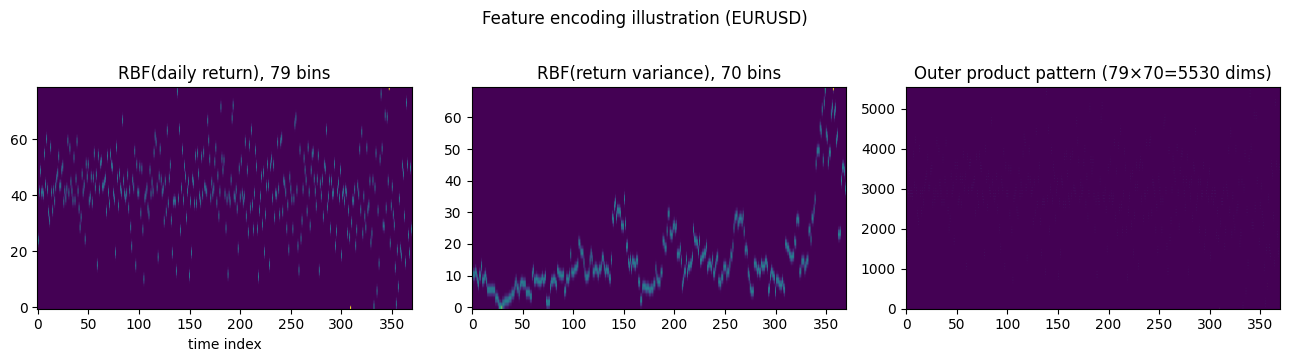

In [3]:
# Use the active feature set (CFG.func -> make_return_variance_features) so the
# per-ticker features here are exactly what Mains.multislice() will encode/run.
per_ticker, csv_lens = FG.load_tickers_features(
    DATA_CSV, ",".join(TICKERS), feature_func=CFG.func, feature_align=W)
demo_sym = TICKERS[-1] #'PG'
feats = per_ticker[demo_sym]["feats"]
n_show = 6000
t_axis = df_raw["Date"].iloc[per_ticker[demo_sym]["first_valid_feat_row"]:][:n_show]

fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
labels = ["value (col 0)", "delta (col 1)",
          "daily return (col 2, target)", "return variance (col 3, secondary)"]
for k, ax in enumerate(axs):
    ax.plot(t_axis, feats[:n_show, k], lw=1)
    ax.set_ylabel(labels[k], fontsize=9)
    ax.grid(alpha=0.3)
axs[0].set_title(f"Rolling return/variance features for {demo_sym} (first {n_show} feature rows)")
plt.tight_layout()
save_fig(fig, 2, f"rolling_features_{demo_sym}")

# RBF encoding on a short slice (multislice uses the pooled stream via build_patterns).
# Primary channel = daily return (col 2, decode target); secondary = variance (col 3).
slice_feats = feats[180:550]
enc_return = FG._make_channel_encoder(slice_feats[:, PRIMARY_COL], RETURN_NBIN, CFG.binmode)
enc_var = FG._make_channel_encoder(slice_feats[:, SECONDARY_COL], VARIANCE_NBIN, CFG.binmode)
p_return = enc_return.encode(slice_feats[:, PRIMARY_COL])
p_var = enc_var.encode(slice_feats[:, SECONDARY_COL])
# Primary is the OUTER factor (matches FeatureGeneration.build_patterns / the C++ marginal).
patterns = (p_return[:, :, None] * p_var[:, None, :]).reshape(len(slice_feats), -1)

fig, axs = plt.subplots(1, 3, figsize=(13, 3.5))
axs[0].imshow(p_return[:].T, aspect="auto", origin="lower", cmap="viridis")
axs[0].set_title(f"RBF(daily return), {RETURN_NBIN} bins")
axs[0].set_xlabel("time index")
axs[1].imshow(p_var[:].T, aspect="auto", origin="lower", cmap="viridis")
axs[1].set_title(f"RBF(return variance), {VARIANCE_NBIN} bins")
axs[2].imshow(patterns[:].T, aspect="auto", origin="lower", cmap="viridis")
axs[2].set_title(f"Outer product pattern ({RETURN_NBIN}×{VARIANCE_NBIN}={patterns.shape[1]} dims)")
plt.suptitle(f"Feature encoding illustration ({demo_sym})", y=1.02)
plt.tight_layout()
save_fig(fig, 3, f"rbf_encoding_{demo_sym}")

# Decode round-trip on the return (target) channel
recon = enc_return.decode(p_return)
print(f"Return decode max |error|: {np.max(np.abs(recon - slice_feats[:, PRIMARY_COL])):.4g}")

K_mode=logarithmic, c=1.2350701240933286, τ_0=39.125, τ_14=751.8599999999997


'figs/FOREX/04_LTSL_delay_ladder.png'

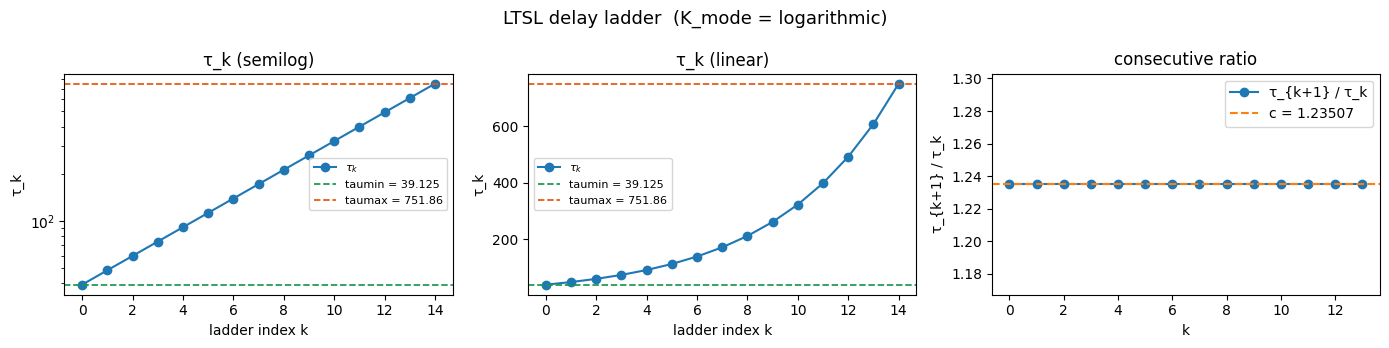

In [4]:
Utils.write_params("Parameters.par", params)
fig = Display.plot_ltsl_delay_ladder("Parameters.par", verbose=True)
save_fig(fig, 4, "LTSL_delay_ladder")

## 3. Block-wise walk-forward schedule

Instead of holding out entire tickers for testing (which leaks calendar structure), **multislice** cuts
the shared timeline into consecutive blocks. Block `b` spans feature rows
`[calendar_start + b·block_step, …)` with `calendar_start = W−1`.

Within each block, patterns are concatenated in order:

`[train_t0, train_t1, …, val_t0, …, test_t0, …]`

The C++ simulator reads one row per block from `schedule.dat` (`trnpat vanpat tenpat` **totals** for that
block, summed over active tickers). Network state (weights + LTSL memory) **carries across blocks** — this
is continual learning on a single long run.

**Warmup (`warmup_pat`, default 50):** at each ticker-to-ticker cut within a phase (`k > 0`), the first
`warmup_pat` patterns are replayed forward-only (LTSL adapts, weights frozen, outputs not logged). RMSE is
computed only on the remaining suffix of each segment. The first ticker in each phase (`k = 0`) is scored
over the full window. Warmup does **not** add calendar rows or change `block_step`; it replays within each
ticker's `trnpat` / `vanpat` / `tenpat` budget. Require each phase length to be **> `warmup_pat + offs`**; set
`warmup_pat 0` to disable.

Candidate blocks (longest history): 1


,block,train_start,test_end,n_active_tickers,schedule_trn,schedule_ten
0,0,2007-01-16,2020-12-18,4,13024,4328


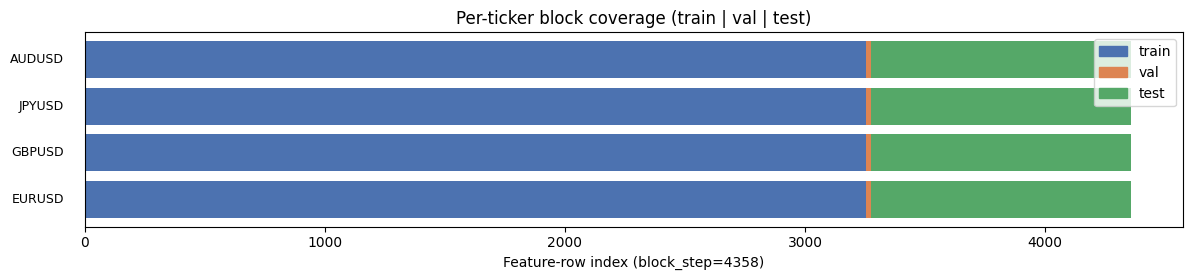

In [5]:
calendar_start = W - 1
max_end = max(d["first_valid_feat_row"] + d["feats"].shape[0] for d in per_ticker.values())
n_blocks = (max_end - calendar_start) // BLOCK_STEP
print(f"Candidate blocks (longest history): {n_blocks}")

# Calendar coverage: train | val | test per block (warmup replays within per_t_len — no extra rows)
phase_colors = {"train": "#4C72B0", "val": "#DD8452", "test": "#55A868"}
fig, ax = plt.subplots(figsize=(12, 0.35 * len(TICKERS[:6]) + 1.5))

for row, sym in enumerate(TICKERS[:6]):
    d = per_ticker[sym]
    fv = d["first_valid_feat_row"]
    n_feat = d["feats"].shape[0]
    for b in range(n_blocks):
        b_start = calendar_start + b * BLOCK_STEP
        sl = b_start - fv
        if sl < 0 or sl + BLOCK_STEP > n_feat:
            continue
        x0 = b
        phase_x = x0
        ax.barh(row, TRNPAT, left=phase_x, color=phase_colors["train"], height=0.8)
        phase_x += TRNPAT
        ax.barh(row, VANPAT, left=phase_x, color=phase_colors["val"], height=0.8)
        phase_x += VANPAT
        ax.barh(row, TENPAT, left=phase_x, color=phase_colors["test"], height=0.8)
    ax.text(-0.02 * BLOCK_STEP, row, sym, ha="right", va="center", fontsize=9)
ax.invert_yaxis() # y axis goes up, so for the first trained ticker to showon top we need to flip the axis
ax.set_xlabel(f"Feature-row index (block_step={BLOCK_STEP})")
ax.set_yticks([])
ax.set_title("Per-ticker block coverage (train | val | test)")
legend_handles = [Patch(color=c, label=k) for k, c in phase_colors.items()]
ax.legend(handles=legend_handles, loc="upper right")
if WARMUP_PAT > 0:
    ax.text(
        0.99, 0.02,
        f"warmup_pat={WARMUP_PAT}: forward replay at ticker transitions (k>0); not extra calendar rows",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8, style="italic")
plt.tight_layout()
save_fig(fig, 5, "block_coverage_train_val_test")



# Map block indices to calendar dates (using AAPL as reference timeline)
ref = per_ticker[TICKERS[-1]]
ref_dates = df_raw["Date"].iloc[ref["first_valid_feat_row"]: ref["first_valid_feat_row"] + ref["feats"].shape[0]]

block_table = []
for b in range(n_blocks):
    sl = calendar_start + b * BLOCK_STEP - ref["first_valid_feat_row"]
    active = [sym for sym in TICKERS
              if 0 <= (calendar_start + b * BLOCK_STEP - per_ticker[sym]["first_valid_feat_row"])
              and (calendar_start + b * BLOCK_STEP - per_ticker[sym]["first_valid_feat_row"] + BLOCK_STEP)
              <= per_ticker[sym]["feats"].shape[0]]
    block_table.append({
        "block": b,
        "train_start": ref_dates.iloc[sl].date() if 0 <= sl < len(ref_dates) else None,
        "test_end": ref_dates.iloc[min(sl + BLOCK_STEP - 1, len(ref_dates)-1)].date() if sl >= 0 else None,
        "n_active_tickers": len(active),
        "schedule_trn": len(active) * TRNPAT,
        "schedule_ten": len(active) * TENPAT,
    })
pd.DataFrame(block_table)

## 4. Run multislice (model) and analyze (metrics)

**Run** (`Mains.run_multislice`) encodes features, writes `schedule.dat` / `features.dat`, and invokes `./ltslmain` once with the full multi-block schedule.

**Analyze** (`Mains.analyze_multislice`) reloads the saved `netw1_outpop_*_dist.bin` streams and computes RMSE cubes — you can rerun this cell after changing metrics without re-invoking the simulator.

In [6]:
# CUDA / driver preflight — run before ltslmain (CUDA-only simulator).
cuda_report = Utils.diagnose_ltslmain_cuda()
if not cuda_report["ok"]:
    print("\n⚠ ltslmain will fail until CUDA is ready (see issues above).")
    print("  Use exefile=None below to skip the simulator if artifacts already exist.")

=== ltslmain / CUDA preflight ===
  GPU: 0000:b3:00.0 VGA compatible controller: NVIDIA Corporation GA104GL [RTX A4000] (rev a1)
  GPU: 0000:b3:00.1 Audio device: NVIDIA Corporation GA104 High Definition Audio Controller (rev a1)
  Running kernel: 7.0.0-30-generic
  Loaded driver: NVRM version: NVIDIA UNIX Open Kernel Module for x86_64  580.173.02  Release Build  (dvs-builder@U22-I3-AK02-24-4)  Tue Jun 23 08:17:01 UTC 2026
  Installed module (modinfo): 580.173.02
  nvidia.ko for this kernel: MISSING
  cudaGetDeviceCount: err=0  devices=1  (cuda error 0)
  ltslmain: /home/fiebig/Dropbox/GIT/BCPNNSim2.2_UC2/tests/UC2-EXTRABRAIN/LTSLtest/ltslmain
  Status: OK — CUDA ready for ltslmain.


In [7]:
# Encode features, write schedule.dat, and invoke ltslmain (~15–20 s for one ticker).
# Set exefile=None to skip the simulator when artifacts are already on disk.
# RUNDIR isolates outputs under a dedicated folder; None keeps legacy CWD layout.
RUNDIR = None
run = Mains.run_multislice(
    PARAMFILE,
    exefile="./ltslmain",
    rundir=RUNDIR,
    verbose=True,
)

Mains.run_multislice: timeseries_file=FOREX.csv
  tickers=['AUDUSD', 'JPYUSD', 'GBPUSD', 'EURUSD']
  trnpat=3256  vanpat=20  tenpat=1082  warmup_pat=0  block_step=4358
  calendar_start=13  max_calendar_end=4371  n_blocks=1
  total feature rows=17432  (per-phase totals: trn=13024, van=80, ten=4328)
paramfile = Parameters_FOREX.par
schedule_file = schedule.dat  (1 blocks; sum trn=13024 van=80 ten=4328)
taup = 13.024
eps = 7.7e-05
K_mode = logarithmic
bdebias = 1
BLOCK 1/1  trnpat=13024 vanpat=80 tenpat=4328  (simstep=0)
Total simsteps = 30452, time elapsed = 743.029 sec


Hj = 1 nactHi = 15 nsilHi = 0 denHi = 15 Mi = 5530 denNi = 82950


In [8]:
# Metrics from saved netw1_outpop_*_dist.bin — safe to rerun without ltslmain.
result = Mains.analyze_multislice(
    PARAMFILE,
    plan=run["plan"],
    rundir=run.get("rundir"),
    metrics=("rmse", "persistence", "hit", "var",
             "quadratic_loss", "smooth_loss", "tick_loss", "firm_loss"),
    var_level=VAR_LEVEL,
    verbose=True,
)

Mains.analyze_multislice: paramfile=Parameters_FOREX.par
  train: mean RMSE = 0.0067864  persistence = 0.0091998  (4/4 valid entries)
  val  : mean RMSE = 0.0044371  persistence = 0.0058703  (4/4 valid entries)
  test : mean RMSE = 0.0046845  persistence = 0.0065216  (4/4 valid entries)


In [9]:
rmse = result["rmse"]          # [n_tickers, 3 phases, n_blocks]
valid = result["valid"]
pers = result["persistence"]
labels = result["tickers"]
n_blocks_run = result["n_blocks"]
phase_names = ["train", "val", "test"]

print(f"RMSE cube shape: {rmse.shape}  (tickers × phases × blocks)")
print(f"Blocks executed: {n_blocks_run}")
print(f"warmup_pat: {result.get('warmup_pat', 0)}")

# Show schedule sidecar written for ltslmain
sched_path = run["artifacts"]["schedule"]
with open(sched_path) as fp:
    sched_lines = fp.read().strip().splitlines()
print(f"\n{sched_path} ({len(sched_lines)} rows):")
for i, line in enumerate(sched_lines):
    print(f"  block {i}: {line}")

RMSE cube shape: (4, 3, 1)  (tickers × phases × blocks)
Blocks executed: 1
warmup_pat: 0

schedule.dat (1 rows):
  block 0: 13024 80 4328


## 5. Test error vs. prior learning (block index)

Block index doubles as **how much calendar history the network has already trained on** (cumulative
continual learning). We expect early blocks to behave differently from later ones — especially around
regime changes (e.g. 2008–2009 for cyclical names).

In [10]:
test_rmse = rmse[:, 2, :]   # phase index 2 = test
test_valid = valid[:, 2, :]
prior_train_days = np.arange(n_blocks_run) * BLOCK_STEP  # feature rows seen before each block

# Calendar year at test-phase start (AAPL reference timeline) for x-axis labels on figs 8–9
_ref = per_ticker["EURUSD"]
_ref_dates = df_raw["Date"].iloc[
    _ref["first_valid_feat_row"] : _ref["first_valid_feat_row"] + _ref["feats"].shape[0]
]
block_year_labels = []
for b in range(n_blocks_run):
    test_start = calendar_start + b * BLOCK_STEP + TRNPAT + VANPAT - _ref["first_valid_feat_row"]
    if 0 <= test_start < len(_ref_dates):
        block_year_labels.append(str(_ref_dates.iloc[test_start].year))
    else:
        block_year_labels.append(str(b))

stockperformance = np.nanmean(test_rmse, axis=1)
# Next Find indices of 5 best and worst performers
bottom5_idx = np.argsort(stockperformance)[-5:][::-1]
top5_idx = np.argsort(stockperformance)[:5]
bottom5_labels = [labels[i] for i in bottom5_idx]
top5_labels = [labels[i] for i in top5_idx]

'figs/FOREX/09_test_rmse_heatmap_tickers_blocks.png'

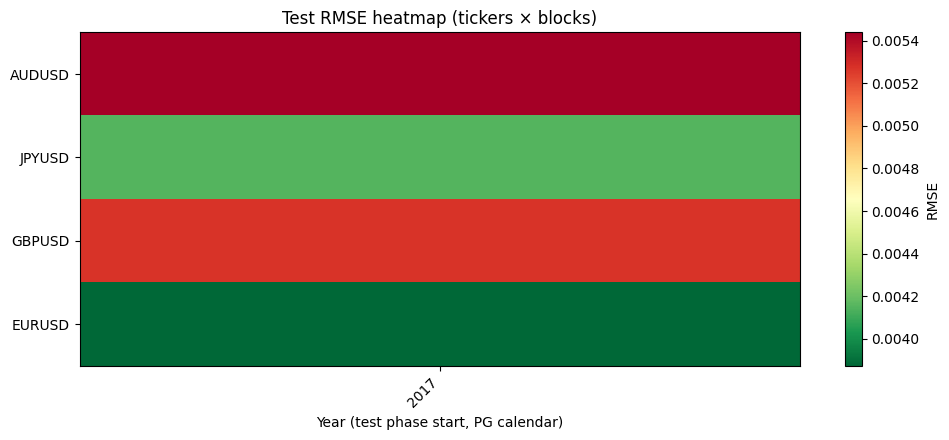

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(test_rmse, aspect="auto", cmap="RdYlGn_r", origin="lower")  # green to red (reversed)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xticks(range(n_blocks_run))
ax.set_xticklabels(block_year_labels, rotation=45, ha="right")
ax.set_xlabel("Year (test phase start, PG calendar)")
ax.set_title("Test RMSE heatmap (tickers × blocks)")
ax.invert_yaxis()
plt.colorbar(im, ax=ax, label="RMSE")
plt.tight_layout()
save_fig(fig, 9, "test_rmse_heatmap_tickers_blocks")

## 6. Cross-stock comparison on the ticker sample

Summarise **mean test RMSE over all blocks** and check dispersion. Consumer staples (KO, PG) often show
lower error than volatile tech / industrial names; crisis-era blocks inflate error for cyclicals.

,ticker,mean_test_rmse,std_test_rmse,max_test_rmse,mean_persistence,beats_persistence
3,EURUSD,0.0039,0.0,0.0039,0.0054,1.0
1,JPYUSD,0.0042,0.0,0.0042,0.0059,1.0
2,GBPUSD,0.0053,0.0,0.0053,0.0072,1.0
0,AUDUSD,0.0054,0.0,0.0054,0.0075,1.0


'figs/FOREX/10_cross_sectional_mean_test_rmse.png'

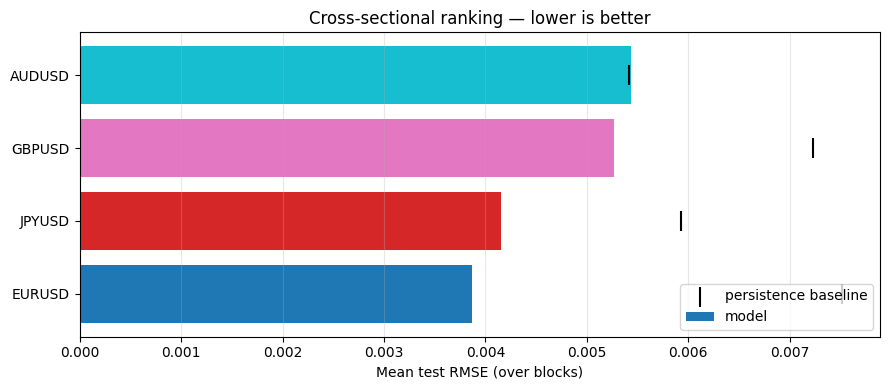

In [12]:
summary_rows = []
for i, sym in enumerate(labels):
    m = test_valid[i]
    summary_rows.append({
        "ticker": sym,
        "mean_test_rmse": float(np.nanmean(test_rmse[i, m])),
        "std_test_rmse": float(np.nanstd(test_rmse[i, m])),
        "max_test_rmse": float(np.nanmax(test_rmse[i, m])),
        "mean_persistence": float(np.nanmean(pers[i, 2, m])),
        "beats_persistence": float(np.nanmean(test_rmse[i, m] < pers[i, 2, m])),
    })
summary = pd.DataFrame(summary_rows).sort_values("mean_test_rmse")
display(summary.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(summary)))
ax.barh(summary["ticker"], summary["mean_test_rmse"], color=colors, label="model")
ax.scatter(summary["mean_persistence"], summary.index, marker="|", s=200, c="k", zorder=3, label="persistence baseline")
ax.set_xlabel("Mean test RMSE (over blocks)")
ax.set_title("Cross-sectional ranking — lower is better")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
save_fig(fig, 10, "cross_sectional_mean_test_rmse")


## 6b. Test prediction and uncertainty (BA)

After a multislice run, model outputs live in the concatenated ``netw1_outpop_*_dist.bin`` streams — one logged row per scored step, in block / phase / ticker order (warmup replay steps are omitted). ``Display.stitch_multislice_ticker`` inverts that layout for a single symbol; ``Display.plot_multislice_prediction(..., phases="test")`` returns ``(fig, ax, rmses)`` so the plot can be adjusted in the notebook before saving; it draws only the **unseen/test** decoded **daily return** (the primary channel) with central credible bands (same convention as ``plot_general_prediction``).


EURUSD: 1081 test steps across 1 blocks
Selected step 3814: block 0  truth=-0.00106  pred=-0.000324  VaR=-0.009662
Click the price or return panel to inspect the pmf at that timestep.


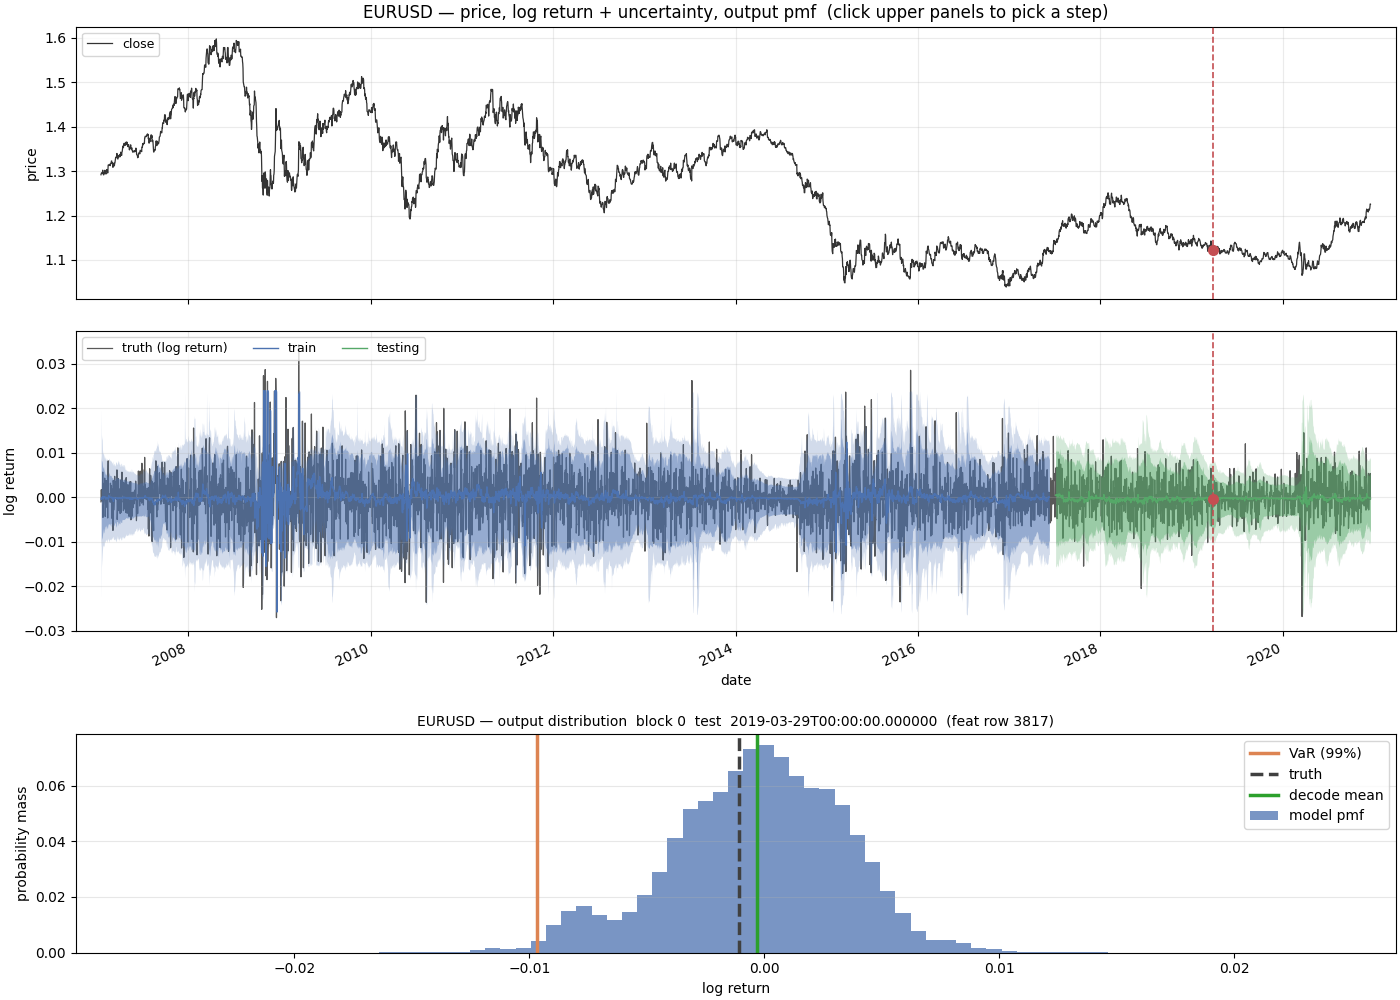

In [13]:
# Interactive price / log-return / output-pmf explorer 
# Click the upper panels to update the pmf
for m in (Utils, FG, Mains, Display):
    importlib.reload(m)

_ip = get_ipython()
try:
    import ipympl  # noqa: F401
    _ip.run_line_magic("matplotlib", "widget")
except ImportError:
    _ip.run_line_magic("matplotlib", "inline")

sym = "EURUSD"
series_sym = Display.stitch_multislice_ticker(
    PARAMFILE, sym, rundir=RUNDIR)
sym_dates = Display.ticker_feat_dates(df_raw["Date"], series_sym)
test_pts = int((series_sym["phase"] == 2).sum())
print(f"{sym}: {test_pts} test steps across "
      f"{series_sym['block'].max() + 1} blocks")

sym_close = df_raw.set_index("Date")[sym].reindex(sym_dates).to_numpy()
test_steps = np.where(series_sym["phase"] == 2)[0]
INITIAL_STEP = int(test_steps[len(test_steps) // 2])   # change to jump on re-run

plt.close("all")
explorer = Display.plot_multislice_explorer(
    PARAMFILE,
    sym,
    result=result,
    series=series_sym,
    dates=sym_dates.values,
    close_prices=sym_close,
    step=INITIAL_STEP,
    phases=["test", "train"],
    confidence_levels=(0.9, 0.99),
    interactive=True,
    rundir=RUNDIR,
)
print(f"Selected step {explorer['step']}: block {explorer['info']['block']}  "
      f"truth={explorer['info']['truth']:.4g}  pred={explorer['info']['pred']:.4g}  "
      f"VaR={explorer['info']['var']:.4g}")
if explorer["cid"] is not None:
    print("Click the price or return panel to inspect the pmf at that timestep.")
else:
    print("Using step slider (install ipympl for click-to-update: %pip install ipympl).")
save_fig(explorer["fig"], 16, f"multislice_explorer_{sym}_step{explorer['step']}")
Display.display_multislice_explorer(explorer)


In [14]:
print(f"DeepVaR losses at 99% VaR level")
for sym in TICKERS:
    #sym = "AUDUSD"
    print ('-----'+str(sym)+'-----')
    
    ti = result["tickers"].index(sym)
    for name in ("quadratic_loss", "smooth_loss", "tick_loss", "firm_loss"):
        print(f"  {name:16s} = {result[name][ti]:.6g}")
    print(f"  violations       = {int(result['n_violations'][ti])}  "
        f"rate = {result['violation_rate'][ti]:.3%}")
    hit = result["hit"][sym]
    hit_ratio = result["hit_ratio"][result["tickers"].index(sym)]
    print(f"  directional hit ratio: {hit_ratio:.2%} over {hit.size} test steps.")


# Todo/Ideas:
# correlate loss with RMSE?
# focus on the LTSL contribution to model efficiency(size) and performance(loss)
#Contact DeepVaR authors about the inconsistencies in the loss metric definitions (first author, but particularly the second author

DeepVaR losses at 99% VaR level
-----AUDUSD-----
  quadratic_loss   = 0.0101762
  smooth_loss      = 0.00772813
  tick_loss        = 0.000183013
  firm_loss        = 0.012977
  violations       = 11  rate = 1.018%
  directional hit ratio: 51.06% over 1081 test steps.
-----JPYUSD-----
  quadratic_loss   = 0.011101
  smooth_loss      = 0.00629042
  tick_loss        = 0.000144693
  firm_loss        = 0.0107432
  violations       = 12  rate = 1.110%
  directional hit ratio: 51.53% over 1081 test steps.
-----GBPUSD-----
  quadratic_loss   = 0.0129514
  smooth_loss      = 0.00805325
  tick_loss        = 0.000179431
  firm_loss        = 0.0134144
  violations       = 14  rate = 1.295%
  directional hit ratio: 49.40% over 1081 test steps.
-----EURUSD-----
  quadratic_loss   = 0.00740067
  smooth_loss      = 0.00590972
  tick_loss        = 0.000126072
  firm_loss        = 0.010251
  violations       = 8  rate = 0.740%
  directional hit ratio: 51.25% over 1081 test steps.


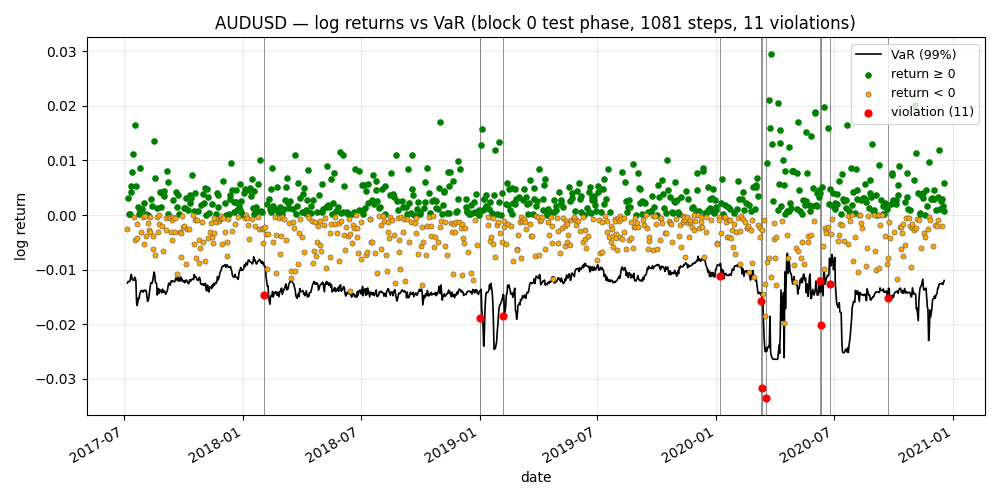

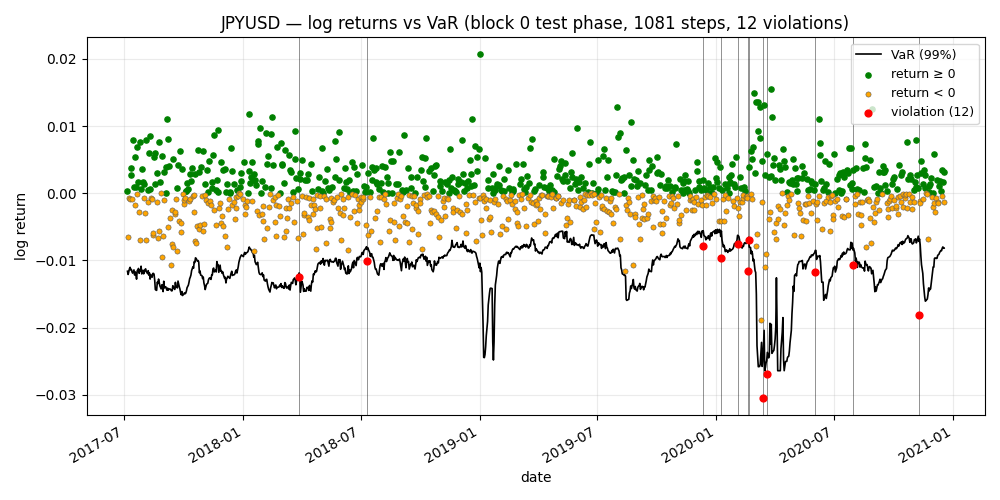

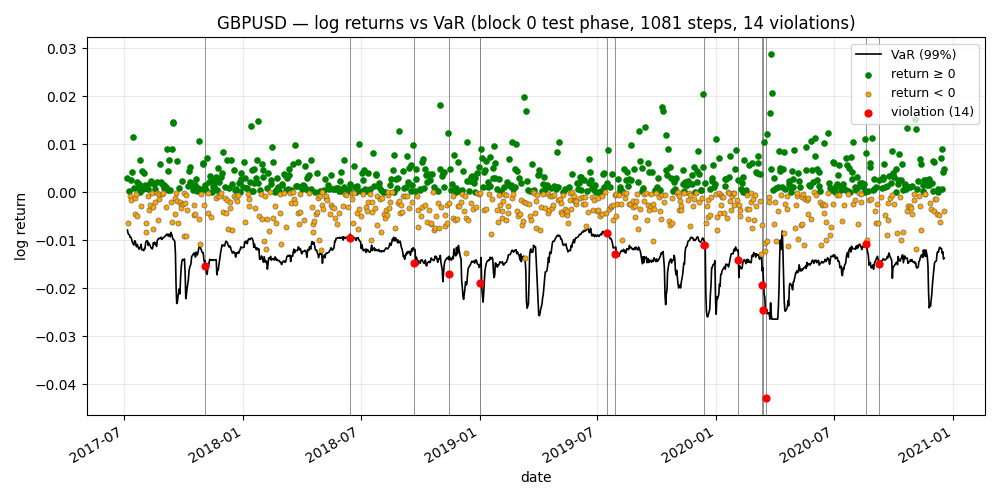

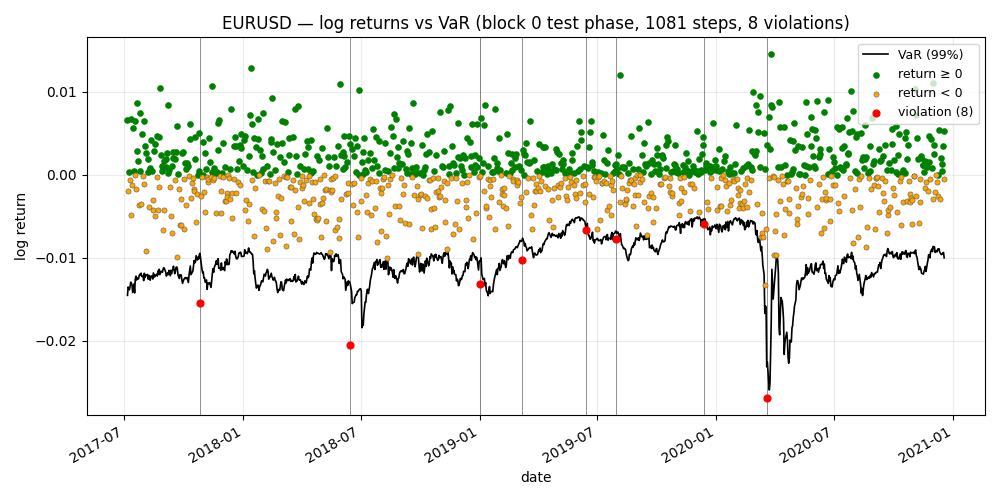

In [15]:
# VaR violation timeline — final block test phase, for all tickers
for sym in TICKERS:
    if "series_sym" not in globals() or series_sym.get("ticker") != sym:
        series_sym = Display.stitch_multislice_ticker(PARAMFILE, sym, rundir=RUNDIR)
        sym_dates = Display.ticker_feat_dates(df_raw["Date"], series_sym)

    last_block = int(series_sym["block"].max())
    idx = np.where(
        (series_sym["phase"] == 2) & (series_sym["block"] == last_block)
    )[0]

    x = sym_dates.iloc[series_sym["x_feat"][idx]].values
    y = series_sym["feats"][series_sym["x_feat"][idx], PRIMARY_COL].astype(float)
    var = np.asarray(result["var"][sym], dtype=float)[idx]

    violation = y < var
    pos_ok = (~violation) & (y >= 0)
    neg_ok = (~violation) & (y < 0)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, var, color="black", lw=1.2, label=f"VaR ({VAR_LEVEL:.0%})")
    ax.scatter(x[pos_ok], y[pos_ok], c="green", s=14, zorder=3, label="return ≥ 0")
    ax.scatter(
        x[neg_ok], y[neg_ok], c="orange", s=14, zorder=3,
        edgecolors="0.35", linewidths=0.4, label="return < 0",
    )
    ax.scatter(
        x[violation], y[violation], c="red", s=24, zorder=4,
        label=f"violation ({violation.sum()})",
    )
    for xi in x[violation]:
        ax.axvline(xi, color="black", lw=0.6, alpha=0.5)

    ax.set_xlabel("date")
    ax.set_ylabel("log return")
    ax.set_title(
        f"{sym} — log returns vs VaR (block {last_block} test phase, "
        f"{len(idx)} steps, {int(violation.sum())} violations)"
    )
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.25)
    fig.autofmt_xdate()
    plt.tight_layout()
    save_fig(fig, 17, f"var_violations_{sym}_last_test")
    plt.show()

## 6c. Matched-window benchmark against DeepVaR

The cells above score the **whole** test phase (2017-07-06 → 2020-12-18, 1081 steps per pair).
DeepVaR backtests a shorter window, **2018-01-01 → 2020-12-18** (928 days — their `E[v] = 9.28`
at the 99% level implies exactly that count), so the two sets of numbers are not directly
comparable: our extra half-year is the calm second half of 2017, which flatters every loss.

This section re-scores the **same frozen model output** on their window. Nothing is retrained —
training ended 2017-06-11, so the model simply runs forward through both windows and we just
slice the stitched per-step `(PnL, VaR)` streams by date.

Alongside the four DeepVaR losses we compute the two backtest hypothesis tests their Tables 3/5/7/9
report, now implemented in `DeepVaRLosses`:

| test | null hypothesis | distribution | rejects |
|------|-----------------|--------------|---------|
| Kupiec `LR_uc` | breach frequency equals 1 − α | χ²(1), crit. 3.84 / 6.63 | wrong *number* of breaches (too many **or** too few) |
| Christoffersen `LR_ind` | breaches are serially independent | χ²(1), crit. 3.84 | **clustered** breaches |
| `LR_cc = LR_uc + LR_ind` | both of the above | χ²(2), crit. 5.99 | either failure mode |

Note that `quadratic_loss` is numerically identical to the violation rate (the `(PnL−VaR)²` term is
~1e-4), so it is a pure *under*-coverage score and is minimised by an arbitrarily deep VaR — read it
together with `LR_uc` rather than on its own. Our `smooth_loss` is positive because we implement
their Eq. 12 as printed (`m = PnL − VaR`); their published values are negative, which only
reproduces under `m = VaR − PnL`, so that column is not compared here.


In [ ]:
import DeepVaRLosses
importlib.reload(DeepVaRLosses)

# ---------------------------------------------------------------- streams --
# Per-ticker test-phase (date, realized log return, VaR) triples. `result["var"]`
# is indexed over the *full* stitched series, so it is sliced with the same
# test_steps indices used for the pnl (cf. MultisliceAnalyze._stitched_step_metrics).
def test_stream(sym):
    series = Display.stitch_multislice_ticker(PARAMFILE, sym, rundir=RUNDIR)
    dates = Display.ticker_feat_dates(df_raw["Date"], series)
    steps = np.where(series["phase"] == 2)[0]
    xf = series["x_feat"][steps]
    return (pd.to_datetime(dates.iloc[xf].values),
            np.asarray(series["feats"][xf, PRIMARY_COL], dtype=float),
            np.asarray(result["var"][sym], dtype=float)[steps])

STREAMS = {sym: test_stream(sym) for sym in TICKERS}

def score(sym, lo=None, hi=None):
    d, pnl, var = STREAMS[sym]
    m = np.ones(len(d), bool)
    if lo is not None:
        m &= d >= pd.Timestamp(lo)
    if hi is not None:
        m &= d <= pd.Timestamp(hi)
    row = DeepVaRLosses.coverage_tests(pnl[m], var[m], VAR_LEVEL)
    row.update(ticker=sym, start=d[m][0].date(), end=d[m][-1].date())
    return row

COLS = ["ticker", "start", "end", "n_test_steps", "n_violations", "violation_rate",
        "mean_var", "quadratic_loss", "smooth_loss", "tick_loss", "firm_loss",
        "LR_uc", "p_uc", "LR_ind", "p_ind", "LR_cc", "p_cc"]

def window_table(lo, hi):
    return pd.DataFrame([score(s, lo, hi) for s in TICKERS])[COLS].set_index("ticker")

full = window_table(None, None)
matched = window_table(*DEEPVAR_WINDOW)

pd.set_option("display.width", 220, "display.max_columns", 40)
for title, tab in (("FULL test phase", full), ("DeepVaR window", matched)):
    v, n = tab["n_violations"].sum(), tab["n_test_steps"].sum()
    lr, p = DeepVaRLosses.kupiec_uc(v, n, VAR_LEVEL)
    print(f"\n===== {title} =====")
    display(tab.round(6))
    print(f"pooled: {int(v)}/{int(n)} = {v/n:.3%}   LR_uc = {lr:.3f} (p = {p:.3f})   "
          f"mean tick = {tab['tick_loss'].mean():.4e}   mean firm = {tab['firm_loss'].mean():.5f}")

# ------------------------------------------------- published DeepVaR table --
# Fatouros et al. (2023), Digital Finance 5:29-56, Tables 2/4/6/8 (losses) and
# 3/5/7/9 (tests), window 2018-01-01..2020-12-18, N = 928, alpha = 0.99.
# NOTE: their JPY series is USDJPY where ours is JPYUSD - opposite sides of the
# same market, so that row is indicative only.
DEEPVAR_PUBLISHED = pd.DataFrame([
    dict(ticker="AUDUSD", n_violations=5, violation_rate=0.00539, quadratic_loss=0.00539,
         tick_loss=0.00020, firm_loss=0.02334, LR_uc=2.386, LR_ind=0.054, LR_cc=2.441),
    dict(ticker="GBPUSD", n_violations=7, violation_rate=0.00754, quadratic_loss=0.00754,
         tick_loss=0.00019, firm_loss=0.02454, LR_uc=0.613, LR_ind=4.258, LR_cc=4.871),
    dict(ticker="JPYUSD", n_violations=8, violation_rate=0.00862, quadratic_loss=0.00862,
         tick_loss=0.00015, firm_loss=0.02146, LR_uc=0.184, LR_ind=0.139, LR_cc=0.324),
    dict(ticker="EURUSD", n_violations=2, violation_rate=0.00216, quadratic_loss=0.00216,
         tick_loss=0.00014, firm_loss=0.01501, LR_uc=8.463, LR_ind=0.009, LR_cc=8.472),
]).set_index("ticker")

CMP = ["n_violations", "violation_rate", "quadratic_loss", "tick_loss", "firm_loss",
       "LR_uc", "LR_ind", "LR_cc"]
MODELS = ("BCPNN-LTSL", "DeepVaR")
head_to_head = pd.concat(
    {"BCPNN-LTSL": matched[CMP], "DeepVaR": DEEPVAR_PUBLISHED.reindex(TICKERS)[CMP]},
    axis=1).swaplevel(axis=1)[[(m, mdl) for m in CMP for mdl in MODELS]]
print("\n===== head to head on the identical window =====")
display(head_to_head.round(5))

print("\nmeans over the four pairs")
for name, frame in (("BCPNN-LTSL", matched), ("DeepVaR   ", DEEPVAR_PUBLISHED)):
    print(f"  {name}  rate={frame['violation_rate'].mean():.4%}  "
          f"quad={frame['quadratic_loss'].mean():.5f}  "
          f"tick={frame['tick_loss'].mean():.4e}  "
          f"firm={frame['firm_loss'].mean():.5f}  "
          f"LR_uc={frame['LR_uc'].mean():.3f}")

CRIT = {"LR_uc": (3.84, 6.63), "LR_ind": (3.84, 6.63), "LR_cc": (5.99, 9.21)}
for name, frame in (("BCPNN-LTSL", matched), ("DeepVaR", DEEPVAR_PUBLISHED)):
    fails = [f"{sym} {stat}={frame.loc[sym, stat]:.2f}"
             f"{'**' if frame.loc[sym, stat] > c99 else '*'}"
             for stat, (c95, c99) in CRIT.items() for sym in frame.index
             if frame.loc[sym, stat] > c95]
    print(f"{name:11s} rejected at 5%: {', '.join(fails) if fails else 'none (0/12 tests)'}")


In [ ]:
# VaR violation timeline restricted to the DeepVaR window (their Fig. 3-6 layout).
# Saved as 23_… so the full-phase figures written by the cell above (17_…) survive.
_ip.run_line_magic("matplotlib", "inline")
LO, HI = (pd.Timestamp(t) for t in DEEPVAR_WINDOW)

for sym in TICKERS:
    x, y, var = STREAMS[sym]
    m = (x >= LO) & (x <= HI)
    x, y, var = x[m], y[m], var[m]

    violation = y < var
    pos_ok = (~violation) & (y >= 0)
    neg_ok = (~violation) & (y < 0)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, var, color="black", lw=1.2, label=f"VaR ({VAR_LEVEL:.0%})")
    ax.scatter(x[pos_ok], y[pos_ok], c="green", s=14, zorder=3, label="return ≥ 0")
    ax.scatter(x[neg_ok], y[neg_ok], c="orange", s=14, zorder=3,
               edgecolors="0.35", linewidths=0.4, label="return < 0")
    ax.scatter(x[violation], y[violation], c="red", s=24, zorder=4,
               label=f"violation ({int(violation.sum())})")
    for xi in x[violation]:
        ax.axvline(xi, color="black", lw=0.6, alpha=0.5)

    exp_v = (1 - VAR_LEVEL) * len(x)
    ax.set_xlabel("date")
    ax.set_ylabel("log return")
    ax.set_title(f"{sym} — log returns vs VaR, DeepVaR window "
                 f"{DEEPVAR_WINDOW[0]} → {DEEPVAR_WINDOW[1]}  "
                 f"({len(x)} steps, {int(violation.sum())} violations, "
                 f"E[v] = {exp_v:.2f})")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.25)
    fig.autofmt_xdate()
    plt.tight_layout()
    save_fig(fig, 23, f"var_violations_{sym}_deepvar_window")
    plt.show()


In [16]:
"""
python3 evolve_hyperparams_v4.py \
--time 172000 \
--objective tick_loss \
--var-level 0.99 \
--base Parameters_FOREX.par \
--work-par Parameters_FOREX_ea_work.par \
--K 2 20 \
--K_mode linear logarithmic \
--return_nbin 2 150 \
--variance_nbin 2 100 \
--variance_window 3 60 \
--binmode rbf rbf-quantile \
--taumin 1 200 \
--taumax 100 1000 \
--pop 24 \
--bdebias 0 1 \
--history ea_forex_trace.jsonl \
--out-json ea_forex_best.json
"""

"""
RESULTS FROM EARLIER INCORRECT TICK LOSS DEFINITION (PUNISH COMMON NON-VIOLATIONS, NUDGE RARE VIOLATIONS):
  "objective": "tick_loss",
  "var_level": 0.99,
  "fitness": 0.0035023482031108907,
  "K": 7,
  "K_mode": "linear",
  "return_nbin": 2,
  "variance_nbin": 30,
  "variance_window": 5,
  "binmode": "rbf-quantile",
  "taumax": 657.0261986359619,
  "rmse_train": 0.006450510831937962,
  "rmse_validation": 0.004174163102615151,
  "rmse_unseen": 0.004727882855589754,
  "rmse_persistence": 0.006004963333788555,
  "quadratic_loss": 0.21798184022118253,
  "smooth_loss": 0.0015693940219685212,
  "tick_loss": 0.0035023482031108907,
  "firm_loss": 0.002186641205212955,
  "violation_rate": 0.21797631862217437,
  "n_violations": 202.5,
  "base_paramfile": "Parameters_FOREX.par",
  "time_budget_s": 61400.0


RESULTS FROM CORRECT TICK LOSS DEFINITION (PUNISH RARE VIOLATIONS, NUDGE COMMON NON-VIOLATIONS):
=== Best after time budget ===                                                                 │
  objective          = tick_loss                                                               │
  var_level          = 0.99                                                                    │
  K                  = 15                                                                      │
  K_mode             = logarithmic                                                             │
  return_nbin        = 79                                                                      │
  variance_nbin      = 70                                                                      │
  variance_window    = 14                                                                      │
  binmode            = rbf                                                                     │
  taumin             = 39.125263203943                                                         │
  taumax             = 751.8555577712317                                                       │
  bdebias            = 1                                                                       │
  tick_loss (minimized) = 0.00015876849426175676                                               │
  rmse_train         = 0.006803040791506418                                                    │
  rmse_validation    = 0.004638180261925258                                                    │
  rmse_unseen        = 0.004722859265373842                                                    │
  rmse_persistence   = 0.006513710160935093                                                    │
  quadratic_loss     = 0.009957237911447085                                                    │
  smooth_loss        = 0.006997856117449157                                                    │
  tick_loss          = 0.00015876849426175676                                                  │
  firm_loss          = 0.011926718332468217                                                    │
  violation_rate     = 0.009956942949407965                                                    │
  n_violations       = 9.25      
"""



'\nRESULTS FROM EARLIER INCORRECT TICK LOSS DEFINITION (PUNISH COMMON NON-VIOLATIONS, NUDGE RARE VIOLATIONS):\n  "objective": "tick_loss",\n  "var_level": 0.99,\n  "fitness": 0.0035023482031108907,\n  "K": 7,\n  "K_mode": "linear",\n  "return_nbin": 2,\n  "variance_nbin": 30,\n  "variance_window": 5,\n  "binmode": "rbf-quantile",\n  "taumax": 657.0261986359619,\n  "rmse_train": 0.006450510831937962,\n  "rmse_validation": 0.004174163102615151,\n  "rmse_unseen": 0.004727882855589754,\n  "rmse_persistence": 0.006004963333788555,\n  "quadratic_loss": 0.21798184022118253,\n  "smooth_loss": 0.0015693940219685212,\n  "tick_loss": 0.0035023482031108907,\n  "firm_loss": 0.002186641205212955,\n  "violation_rate": 0.21797631862217437,\n  "n_violations": 202.5,\n  "base_paramfile": "Parameters_FOREX.par",\n  "time_budget_s": 61400.0\n\n\nRESULTS FROM CORRECT TICK LOSS DEFINITION (PUNISH RARE VIOLATIONS, NUDGE COMMON NON-VIOLATIONS):\n=== Best after time budget ===                                  

## 7. Evolutionary search post-mortem (8-D parameter space, `tick_loss` objective)

The ~6.5-hour run driven by `evolve_hyperparams_v4.py` logged every evaluation to
`ea_forex_trace.jsonl` with **`--objective tick_loss`** (DeepVaR left-tail score at
VaR level 0.99). Below we load that trace and inspect:

1. **Search trajectory** — how validation tick loss improved over wall time and generations.
2. **Near-optimal manifold** — where the 0.5%-of-best evaluations live in parameter space.
3. **Tick loss vs RMSE** — how the risk objective relates to point-forecast error across
   the searched genotypes, and what that implies for multi-objective tuning.

Trace: 318 successful evaluations (299 unique genotypes), 0 failed (inf fitness)
Generations: 15   wall time: 47.6 h   objective: tick_loss
Best tick loss: 0.000159  (gen 14, t=46.6 h)
Near-optimal (≤0.5% above best): 44 evals, 35 unique genotypes
New-best events: 14
  (all near-optimal genotypes share K_mode=logarithmic)
  (all near-optimal genotypes share binmode=rbf)
Pareto front (tick_loss vs validation RMSE): 12 points
Pearson r(tick_loss, rmse_validation) = -0.288
Spearman ρ (near-optimal) = 0.553

Best genotype (ea_forex_best.json):
  K                = 15
  K_mode           = logarithmic
  return_nbin      = 79
  variance_nbin    = 70
  variance_window  = 14
  binmode          = rbf
  taumax           = 751.8555577712317
  bdebias          = 1
  rmse_validation  = 0.004638
  violation_rate   = 0.996%


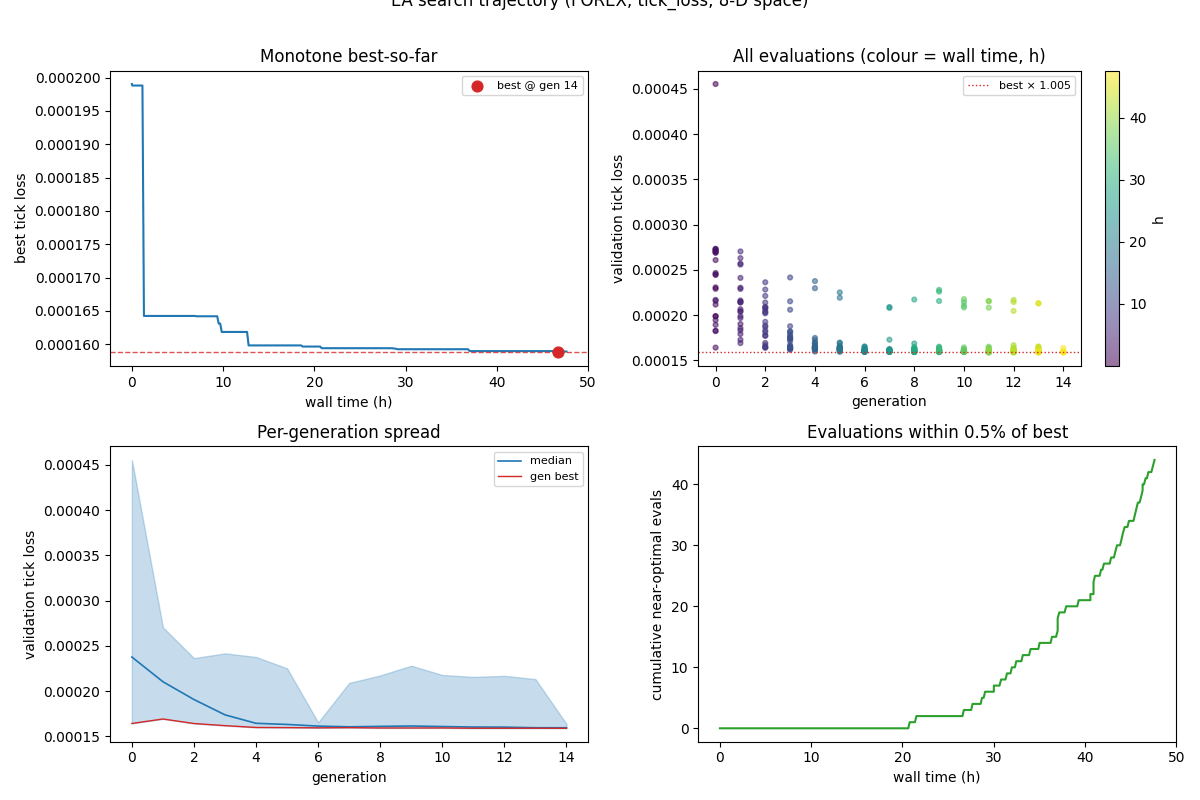

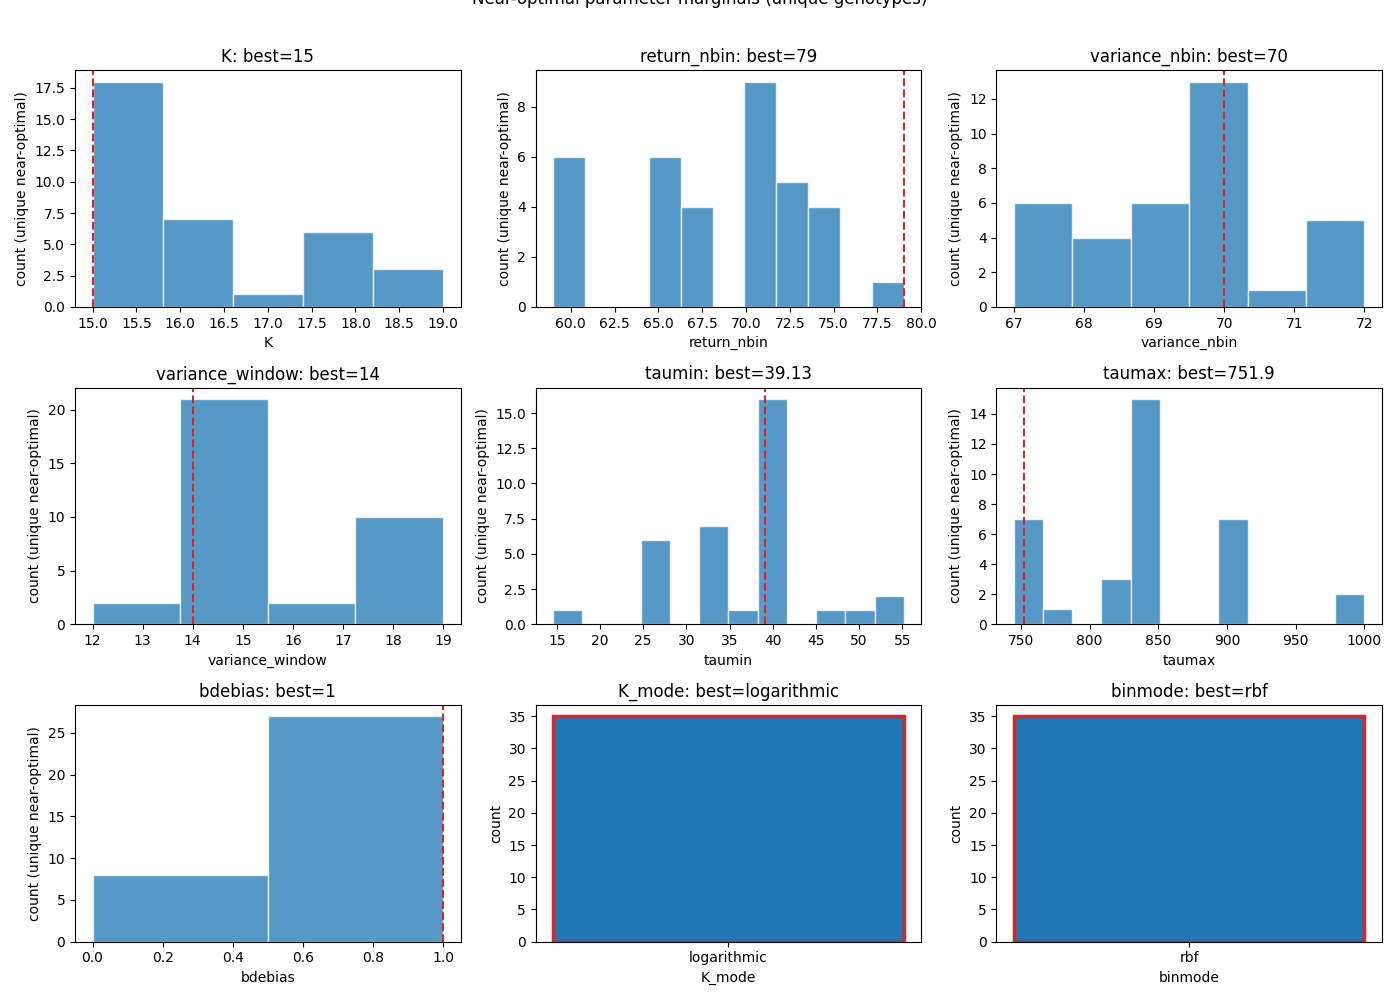

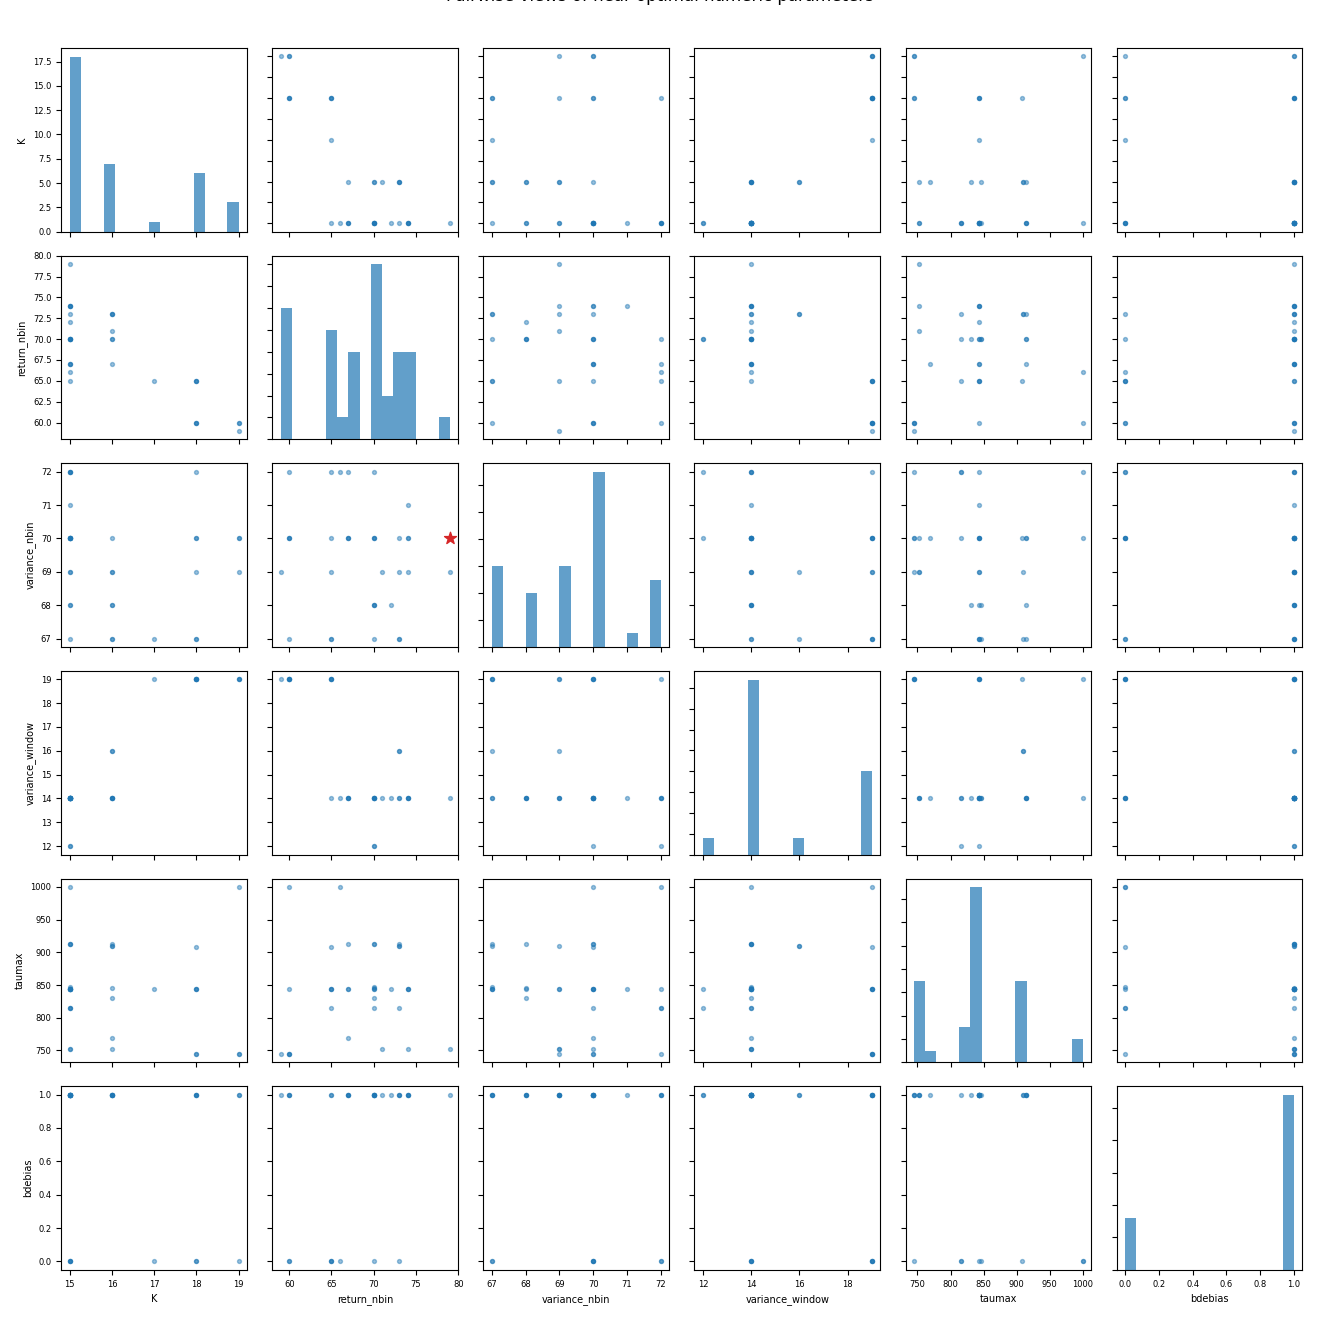

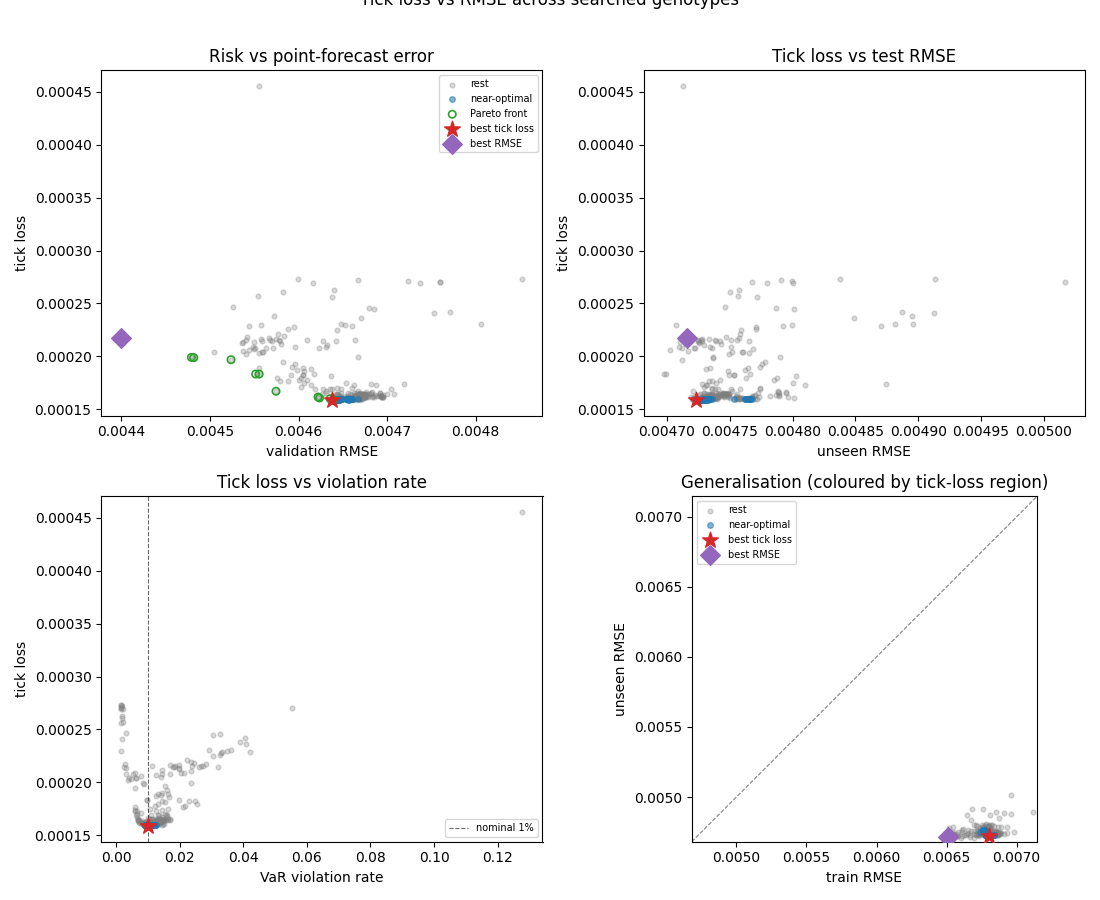


Parameter summary (numeric medians / categorical modes):


,K,K_mode,return_nbin,variance_nbin,variance_window,binmode,taumax,bdebias
all,17.0,logarithmic,65.0,70.0,18.0,rbf,744.803372,1.0
near_optimal,15.0,logarithmic,70.0,70.0,14.0,rbf,843.155849,1.0
best,15,logarithmic,79,70,14,rbf,751.855558,1



Metric summary:


,tick_loss,rmse_train,rmse_validation,rmse_unseen,rmse_persistence,violation_rate
best_tick_loss,0.000159,0.006803,0.004638,0.004723,0.006514,0.009957
best_rmse,0.000217,0.006513,0.004400,0.004716,0.006470,0.002691
near_opt_median,0.000159,0.006788,0.004647,0.004731,0.006514,0.009957


In [17]:
# --- EA trace analysis: trajectory, near-optimal region, tick_loss vs RMSE ------------
import json
from pathlib import Path

TRACE_PATH = "ea_forex_trace.jsonl"
BEST_PATH = "ea_forex_best.json"

PARAM_COLS = [
    "K", "K_mode", "return_nbin", "variance_nbin",
    "variance_window", "binmode", "taumax", "bdebias",
]
NUM_COLS = ["K", "return_nbin", "variance_nbin", "variance_window", "taumax", "bdebias"]
CAT_COLS = ["K_mode", "binmode"]
METRIC_COLS = [
    "tick_loss", "rmse_train", "rmse_validation", "rmse_unseen",
    "rmse_persistence", "violation_rate",
]


def _load_jsonl(path):
    rows = [json.loads(line) for line in Path(path).read_text().splitlines() if line.strip()]
    return pd.DataFrame(rows)


def _dedupe_best(df, key_cols=PARAM_COLS):
    return (
        df.sort_values("fitness")
        .drop_duplicates(subset=key_cols, keep="first")
        .reset_index(drop=True)
    )


def _pareto_mask(df, x_col, y_col):
    """True for rows on the Pareto front (lower is better on both axes)."""
    pts = df[[x_col, y_col]].to_numpy()
    keep = np.ones(len(df), dtype=bool)
    for i, (x, y) in enumerate(pts):
        dominated = (pts[:, 0] <= x) & (pts[:, 1] <= y) & ((pts[:, 0] < x) | (pts[:, 1] < y))
        if dominated.any():
            keep[i] = False
    return keep


# --- load -----------------------------------------------------------------------
ea_all = _load_jsonl(TRACE_PATH)
n_failed = int((~np.isfinite(ea_all["fitness"])).sum())
ea = ea_all[np.isfinite(ea_all["fitness"])].copy()
best_rec = json.loads(Path(BEST_PATH).read_text())
best_fit = float(best_rec["fitness"])
near_eps = 1.005  # within 0.5 % of best tick loss
near = ea[ea["fitness"] <= best_fit * near_eps].copy()
near_u = _dedupe_best(near)

n_gens = int(ea["gen"].max()) + 1
n_evals = len(ea)
n_unique = _dedupe_best(ea).shape[0]
wall_h = ea["t"].max() / 3600.0
best_row = ea.loc[ea["fitness"].idxmin()]
improve_gens = ea.index[ea["best_fitness"].diff() < -1e-9]
best_rmse_row = ea.loc[ea["rmse_validation"].idxmin()]
pareto = ea[_pareto_mask(ea, "tick_loss", "rmse_validation")]

print(f"Trace: {n_evals} successful evaluations ({n_unique} unique genotypes), "
      f"{n_failed} failed (inf fitness)")
print(f"Generations: {n_gens}   wall time: {wall_h:.1f} h   objective: {best_rec['objective']}")
print(f"Best tick loss: {best_fit:.6f}  (gen {int(best_row['gen'])}, t={best_row['t']/3600:.1f} h)")
print(f"Near-optimal (≤{100*(near_eps-1):.1f}% above best): {len(near)} evals, "
      f"{len(near_u)} unique genotypes")
print(f"New-best events: {len(improve_gens)}")
for col in CAT_COLS:
    modes = near_u[col].value_counts()
    if len(modes) == 1:
        print(f"  (all near-optimal genotypes share {col}={modes.index[0]})")
print(f"Pareto front (tick_loss vs validation RMSE): {len(pareto)} points")
print(f"Pearson r(tick_loss, rmse_validation) = {ea['tick_loss'].corr(ea['rmse_validation']):.3f}")
print(f"Spearman ρ (near-optimal) = "
      f"{near['tick_loss'].corr(near['rmse_validation'], method='spearman'):.3f}")
print("\nBest genotype (ea_forex_best.json):")
for c in PARAM_COLS:
    print(f"  {c:16s} = {best_rec[c]}")
print(f"  rmse_validation  = {best_rec['rmse_validation']:.6f}")
print(f"  violation_rate   = {best_rec['violation_rate']:.3%}")

# --- 1. Search trajectory -------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
ax.plot(ea["t"] / 3600, ea["best_fitness"], color="C0", lw=1.5)
ax.axhline(best_fit, color="C3", ls="--", lw=1, alpha=0.8)
ax.scatter(
    best_row["t"] / 3600, best_fit, color="C3", s=60, zorder=5,
    label=f"best @ gen {int(best_row['gen'])}",
)
ax.set_xlabel("wall time (h)")
ax.set_ylabel("best tick loss")
ax.set_title("Monotone best-so-far")
ax.legend(fontsize=8)

ax = axes[0, 1]
sc = ax.scatter(
    ea["gen"], ea["fitness"], c=ea["t"] / 3600, s=12, alpha=0.55, cmap="viridis"
)
ax.axhline(best_fit * near_eps, color="C3", ls=":", lw=1, label=f"best × {near_eps}")
ax.set_xlabel("generation")
ax.set_ylabel("validation tick loss")
ax.set_title("All evaluations (colour = wall time, h)")
fig.colorbar(sc, ax=ax, label="h")
ax.legend(fontsize=8)

ax = axes[1, 0]
gen_stats = ea.groupby("gen")["fitness"].agg(["min", "median", "max"])
ax.fill_between(gen_stats.index, gen_stats["min"], gen_stats["max"], alpha=0.25, color="C0")
ax.plot(gen_stats.index, gen_stats["median"], color="C0", lw=1.2, label="median")
ax.plot(gen_stats.index, gen_stats["min"], color="C3", lw=1.0, label="gen best")
ax.set_xlabel("generation")
ax.set_ylabel("validation tick loss")
ax.set_title("Per-generation spread")
ax.legend(fontsize=8)

ax = axes[1, 1]
cum_near = (ea["fitness"] <= best_fit * near_eps).cumsum()
ax.plot(ea["t"] / 3600, cum_near, color="C2", lw=1.5)
ax.set_xlabel("wall time (h)")
ax.set_ylabel("cumulative near-optimal evals")
ax.set_title(f"Evaluations within {100*(near_eps-1):.1f}% of best")

fig.suptitle("EA search trajectory (FOREX, tick_loss, 8-D space)", y=1.01, fontsize=12)
fig.tight_layout()
save_fig(fig, 18, "ea_trajectory")
plt.show()

# --- 2. Near-optimal parameter marginals ----------------------------------------
MARGINAL_NUM_COLS = [
    "K", "return_nbin", "variance_nbin", "variance_window",
    "taumin", "taumax", "bdebias",
]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(MARGINAL_NUM_COLS):
    ax = axes[i]
    ax.hist(near_u[col], bins=min(25, near_u[col].nunique()), color="C0", alpha=0.75, edgecolor="white")
    ax.axvline(best_rec[col], color="C3", ls="--", lw=1.5)
    ax.set_xlabel(col)
    ax.set_ylabel("count (unique near-optimal)")
    ax.set_title(f"{col}: best={best_rec[col]:.4g}" if col in ("taumin", "taumax") else f"{col}: best={best_rec[col]}")

for j, col in enumerate(CAT_COLS):
    ax = axes[len(MARGINAL_NUM_COLS) + j]
    counts = near_u[col].value_counts()
    bars = ax.bar(counts.index.astype(str), counts.values, color=["C0", "C1"][: len(counts)])
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    best_val = str(best_rec[col])
    for b, lab in zip(bars, counts.index.astype(str)):
        if lab == best_val:
            b.set_edgecolor("C3")
            b.set_linewidth(2.5)
    ax.set_title(f"{col}: best={best_val}")

fig.suptitle("Near-optimal parameter marginals (unique genotypes)", y=1.01, fontsize=12)
fig.tight_layout()
save_fig(fig, 19, "ea_near_optimal_marginals")
plt.show()

# --- 3. Pairwise numeric scatter (near-optimal) -----------------------------------
pair_cols = NUM_COLS
n_p = len(pair_cols)
fig, axes = plt.subplots(n_p, n_p, figsize=(2.2 * n_p, 2.2 * n_p))
for r, ycol in enumerate(pair_cols):
    for c, xcol in enumerate(pair_cols):
        ax = axes[r, c]
        if r == c:
            ax.hist(near_u[xcol], bins=15, color="C0", alpha=0.7)
        else:
            ax.scatter(near_u[xcol], near_u[ycol], s=8, alpha=0.45, c="C0")
            if xcol == "return_nbin" and ycol == "variance_nbin":
                ax.scatter(
                    best_rec["return_nbin"], best_rec["variance_nbin"],
                    c="C3", s=80, marker="*", zorder=5,
                )
        if r == n_p - 1:
            ax.set_xlabel(xcol, fontsize=7)
        else:
            ax.set_xticklabels([])
        if c == 0:
            ax.set_ylabel(ycol, fontsize=7)
        else:
            ax.set_yticklabels([])
        ax.tick_params(labelsize=6)
fig.suptitle("Pairwise views of near-optimal numeric parameters", y=1.01, fontsize=12)
fig.tight_layout()
save_fig(fig, 20, "ea_near_optimal_pairs")
plt.show()

# --- 4. Tick loss vs RMSE (and related metrics) ---------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
rest = ea[ea["fitness"] > best_fit * near_eps]

ax = axes[0, 0]
ax.scatter(rest["rmse_validation"], rest["tick_loss"], s=12, alpha=0.3, c="C7", label="rest")
ax.scatter(near["rmse_validation"], near["tick_loss"], s=16, alpha=0.55, c="C0", label="near-optimal")
ax.scatter(pareto["rmse_validation"], pareto["tick_loss"], s=28, facecolors="none",
           edgecolors="C2", linewidths=1.2, label="Pareto front")
ax.scatter(best_rec["rmse_validation"], best_rec["tick_loss"], c="C3", s=140, marker="*",
           zorder=5, label="best tick loss")
ax.scatter(best_rmse_row["rmse_validation"], best_rmse_row["tick_loss"], c="C4", s=100,
           marker="D", zorder=5, label="best RMSE")
ax.set_xlabel("validation RMSE")
ax.set_ylabel("tick loss")
ax.set_title("Risk vs point-forecast error")
ax.legend(fontsize=7, loc="best")

ax = axes[0, 1]
ax.scatter(rest["rmse_unseen"], rest["tick_loss"], s=12, alpha=0.3, c="C7")
ax.scatter(near["rmse_unseen"], near["tick_loss"], s=16, alpha=0.55, c="C0")
ax.scatter(best_rec["rmse_unseen"], best_rec["tick_loss"], c="C3", s=140, marker="*", zorder=5)
ax.scatter(best_rmse_row["rmse_unseen"], best_rmse_row["tick_loss"], c="C4", s=100,
           marker="D", zorder=5)
ax.set_xlabel("unseen RMSE")
ax.set_ylabel("tick loss")
ax.set_title("Tick loss vs test RMSE")

ax = axes[1, 0]
ax.scatter(rest["violation_rate"], rest["tick_loss"], s=12, alpha=0.3, c="C7")
ax.scatter(near["violation_rate"], near["tick_loss"], s=16, alpha=0.55, c="C0")
ax.axvline(1 - VAR_LEVEL, color="k", ls="--", lw=0.8, alpha=0.6,
           label=f"nominal {(1-VAR_LEVEL):.0%}")
ax.scatter(best_rec["violation_rate"], best_rec["tick_loss"], c="C3", s=140, marker="*", zorder=5)
ax.set_xlabel("VaR violation rate")
ax.set_ylabel("tick loss")
ax.set_title("Tick loss vs violation rate")
ax.legend(fontsize=7)

ax = axes[1, 1]
ax.scatter(rest["rmse_train"], rest["rmse_unseen"], s=12, alpha=0.3, c="C7", label="rest")
ax.scatter(near["rmse_train"], near["rmse_unseen"], s=16, alpha=0.55, c="C0", label="near-optimal")
ax.scatter(best_rec["rmse_train"], best_rec["rmse_unseen"], c="C3", s=140, marker="*",
           zorder=5, label="best tick loss")
ax.scatter(best_rmse_row["rmse_train"], best_rmse_row["rmse_unseen"], c="C4", s=100,
           marker="D", zorder=5, label="best RMSE")
lim = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lim, lim, "k--", lw=0.8, alpha=0.5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("train RMSE")
ax.set_ylabel("unseen RMSE")
ax.set_title("Generalisation (coloured by tick-loss region)")
ax.legend(fontsize=7)
ax.set_aspect("equal")

fig.suptitle("Tick loss vs RMSE across searched genotypes", y=1.01, fontsize=12)
fig.tight_layout()
save_fig(fig, 21, "ea_tick_loss_vs_rmse")
plt.show()

# --- summary table --------------------------------------------------------------
def _param_summary(df, cols):
    out = {}
    for c in cols:
        out[c] = df[c].median() if c in NUM_COLS else df[c].mode().iloc[0]
    return out

summary = pd.DataFrame({
    "all": _param_summary(ea, PARAM_COLS),
    "near_optimal": _param_summary(near_u, PARAM_COLS),
    "best": {c: best_rec[c] for c in PARAM_COLS},
}).T
print("\nParameter summary (numeric medians / categorical modes):")
display(summary)

metric_summary = pd.DataFrame({
    "best_tick_loss": {m: best_rec[m] for m in METRIC_COLS if m in best_rec},
    "best_rmse": {m: best_rmse_row[m] for m in METRIC_COLS},
    "near_opt_median": {m: near[m].median() for m in METRIC_COLS},
}).T
print("\nMetric summary:")
display(metric_summary.round(6))

### Takeaways

This notebook is an end-to-end FOREX study of the **multislice** continual-learning
pipeline with the **`return_variance`** feature set: the network predicts the next-day
**log return**, conditioned on a left-sided trailing **return variance** side channel.
Four FX pairs (AUDUSD, JPYUSD, GBPUSD, EURUSD) share one walk-forward schedule; DeepVaR
scores (especially **tick loss** at VaR 99%) sit alongside RMSE as the risk-relevant
objective. What follows summarizes the pipeline lessons, the bug fixes that unlocked
sensible VaR behaviour, and the post-fix evolutionary search.

#### Pipeline and evaluation
- **Features & encoding.** Daily log returns + trailing variance are encoded by two
  independent 1-D RBF grids (`return_nbin` × `variance_nbin` outer product). Centre
  layout is controlled by `binmode`: **`rbf`** (linear centres on a winsorized range) or
  **`rbf-quantile`** (empirical-quantile centres with adaptive widths).
- **Multislice protocol.** All tickers train / validate / test on successive calendar
  blocks inside one `ltslmain` process, so LTSL state and BCPNN weights carry across
  ticker and block boundaries — the setup intended for continual FX learning rather
  than i.i.d. hold-out tickers.
- **Objectives.** Point forecast quality (RMSE vs a persistence baseline) and left-tail
  risk (DeepVaR quadratic / smooth / tick / firm losses) are both reported. **Tick loss**
  is the primary evolutionary objective: it punishes rare VaR breaches and nudges
  non-breaches, targeting a ~1% violation rate at `var_level=0.99`.

#### Bug fixes that retuned the model
Two implementation bugs previously dominated the apparent “bias” of the estimator
(see also `nb-SYNTH.ipynb`):

1. **RBF σ on log-return scale.** `from_linear_winsor` used `sigma = 1/n_centers` in
   absolute units — fine for normalized prices, but ≈ the whole winsor width for log
   returns — so `binmode=rbf` encodings collapsed toward uniform. The scale-invariant
   default `sigma = (hi−lo)/n_centers` restored meaningful linear binning.
2. **`eps` never reached the projection.** The `.par` `eps` was parsed and printed, but
   `Prj` kept the library default `1e-7`. Rare outer joint bins therefore built
   multi-nat sampling noise in the log-odds; softmax readouts sprouted spurious outer
   peaks. Wiring `seteps(eps)` restored proper Laplace-style floors.

With those fixes in place, a *systematic* residual remained: the trace floor
`Z = act·(1−eps) + eps` injects uniform mass into the learned prior `Bj = log(Pj)`,
flattening the recalled pmf and overweighting the tails — exactly the wrong direction
for VaR.

#### `bdebias`: undoing the prior-floor bias
- **What it does.** At weight-update time, only the bias / prior term is debiased:
  `p̂ = max((Pj − eps)/(1 − eps), eps²)`, `Bj = log(p̂)`. Pairwise weights
  `Wji = log(Pji/(Pi·Pj))` keep the floor (so rare coincidences stay regularized).
- **Why it helps *after* the eps fix.** Before `eps` was wired, the floor was
  effectively off (`1e-7`); “debiasing” a near-zero floor was meaningless, and the
  dominant failure mode was sampling noise. Once `eps` is real (~`1/(1+trnpat)`), the
  floor *does* regularize weights but also *does* compress the prior — so `bdebias=1`
  becomes the complementary half of the fix: keep weight regularization, remove prior
  admixture.
- **FOREX evidence.** The post-fix EA best genotype uses **`bdebias=1`**. On the
  stationary Gaussian probe in `nb-SYNTH.ipynb`, `bdebias=1` is what lets the average
  pmf track the true bell and the backtest hit the nominal 1% violation rate.

#### Evolutionary search (post-fix, `evolve_hyperparams_v4.py`)
An earlier run under the **incorrect tick-loss polarity** (and pre-fix model) found a
spurious “optimum” with ~22% violations and tick loss ≈ 0.0035 — not comparable to
current scores.

The superseding ~48 h search (`ea_forex_trace.jsonl` / `ea_forex_best.json`) after the
bug fixes and correct tick-loss definition:

| | |
|---|---|
| Coverage | 318 successful evals, 299 unique genotypes, 15 gens, 0 `inf` failures, 14 new-best events |
| Best tick loss | **0.000159** (≈22× below the buggy-definition “best”) |
| Violation rate | **0.996%** (target 1% at VaR 99%) |
| Best genotype | `K=15`, **`K_mode=logarithmic`**, `return_nbin=79`, `variance_nbin=70`, `variance_window=14`, **`binmode=rbf`**, `taumin≈39`, `taumax≈752`, **`bdebias=1`** |

Near-optimal band (≤0.5% above best): **every** retained genotype shares
**`K_mode=logarithmic`** and **`binmode=rbf`**. That is a clean reversal of the
pre-fix takeaway that favoured `rbf-quantile` and short `taumax`.

Tick loss and validation RMSE remain only weakly / partially coupled globally
(Pearson *r* ≈ −0.29); a small Pareto front still exists, so RMSE is a useful secondary
check but a poor proxy objective for tail calibration. The current `.par` baseline
(`Parameters_FOREX.par`) has been updated to this best genotype.

#### Why `rbf` beats `rbf-quantile` for tick loss (hypothesis)
`rbf-quantile` places centres at empirical mid-quantiles, so mass is spent on the
**bulk** of the return distribution. The leftmost centre sits near the `(0.5/n)`
quantile — for moderate `n`, that is already around the 1% VaR level, leaving almost
no grid resolution *beyond* the tail you need to score (the saturation effect studied
in `nb-SYNTH.ipynb`).

**`rbf` (linear winsor grid)** spreads centres evenly across the winsorized range and
therefore allocates relatively more bins to the **long left tail** of log returns —
precisely the region DeepVaR / tick loss care about. FOREX returns are heavier-tailed
and more non-stationary than the synthetic Gaussian, so that extra left-tail
discretization appears to matter more here than bulk resolution. The EA’s unanimous
near-optimal preference for `rbf` (with large `return_nbin`) is consistent with that
story; SYNTH remains the cleaner probe that first made the centre-placement argument
visible.

*(Caveat: on stationary Gaussian SYNTH with `bdebias` on, `rbf-quantile` can already
pass a 1% backtest at `n≈50`; the FOREX preference for linear binning is about
*risk-score* headroom on real FX tails, not a claim that quantile binning is
universally wrong.)*

#### Logarithmic vs linear LTSL time-constant grids
`K_mode=logarithmic` spaces the `K` temporal kernels geometrically between `taumin`
and `taumax`; `linear` spaces them evenly. For a wide τ range (here ~40 → ~750 pattern
steps), a linear grid wastes kernels on nearly redundant slow scales, while a log grid
gives roughly constant relative coverage from fast to slow — more efficient use of a
fixed `K`. The EA’s unanimous near-optimal preference for **logarithmic** (and the
1-D `K`×`K_mode` sweep) supports that efficiency story for daily FX VaR, where both
short-lived shocks and multi-month regimes matter.

#### Practical recipe (current)
For FOREX VaR-oriented tuning after the eps / σ / tick-loss fixes:
**`binmode=rbf`**, **`K_mode=logarithmic`**, **`bdebias=1`**, relatively **fine** return
and variance grids, and a **wide** `[taumin, taumax]` span — then monitor violation rate
≈ 1% and RMSE as secondary sanity checks. Dedicated 1-D sweeps (§7) remain useful for
local sensitivity around this EA optimum.


## 7. Picking the right parameters
Dedicated 1-D sweeps over `K`, `K_mode`, `taumax`, `return_nbin`, `variance_nbin`, `variance_window`, and
`binmode` (via `Parameters_multislice_return_variance_work.par` so the baseline `.par` is never clobbered).

Parameter sweep: 2 combinations to run (metric=tick_loss)
  [1/2] {'binmode': 'rbf'} -> tick_loss = 1.5830e-04  (743.7s, ~12m23s left)
  [2/2] {'binmode': 'rbf-quantile'} -> tick_loss = 2.1422e-04  (744.7s, ~0m00s left)
  Saved: figs/FOREX/sweep_binmode.png
Parameter sweep: 6 combinations to run (metric=tick_loss)
  [1/6] {'taumin': 5} -> tick_loss = 1.5919e-04  (745.9s, ~62m09s left)
  [2/6] {'taumin': 10} -> tick_loss = 1.5836e-04  (745.1s, ~49m42s left)
  [3/6] {'taumin': 20} -> tick_loss = 1.5782e-04  (746.8s, ~37m17s left)
  [4/6] {'taumin': 40} -> tick_loss = 1.5835e-04  (745.0s, ~24m51s left)
  [5/6] {'taumin': 60} -> tick_loss = 1.5970e-04  (744.8s, ~12m25s left)
  [6/6] {'taumin': 80} -> tick_loss = 1.6191e-04  (742.3s, ~0m00s left)
  Saved: figs/FOREX/sweep_taumin.png
Parameter sweep: 5 combinations to run (metric=tick_loss)
  [1/5] {'taumax': 100} -> tick_loss = 1.7152e-04  (745.9s, ~49m43s left)
  [2/5] {'taumax': 500} -> tick_loss = 1.5962e-04  (743.2s, ~37m13s left)
  [3/

ValueError: build_multislice_plan() found no usable blocks for 'Parameters_FOREX_sweeps.par'. block_step=4358, longest ticker history=4351 feature rows.

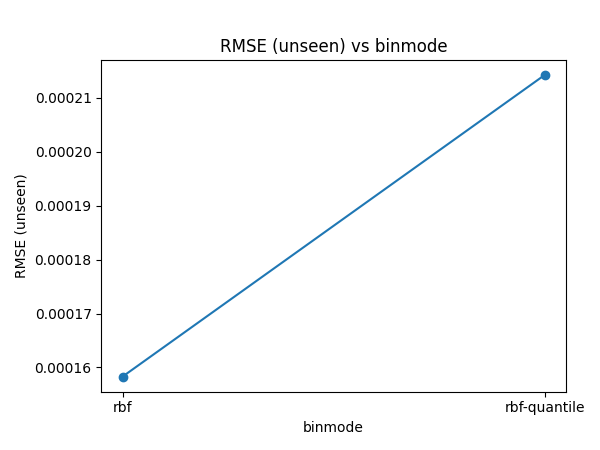

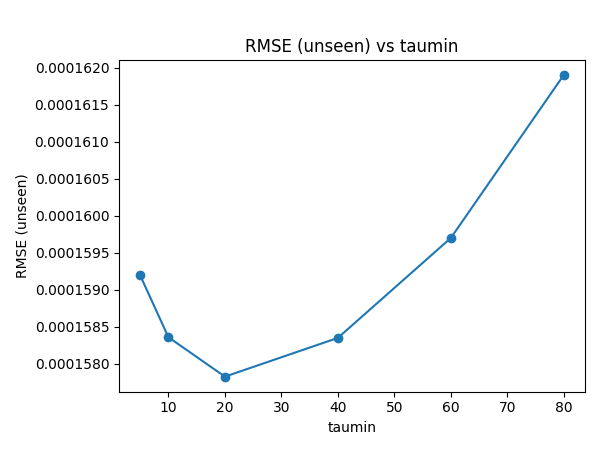

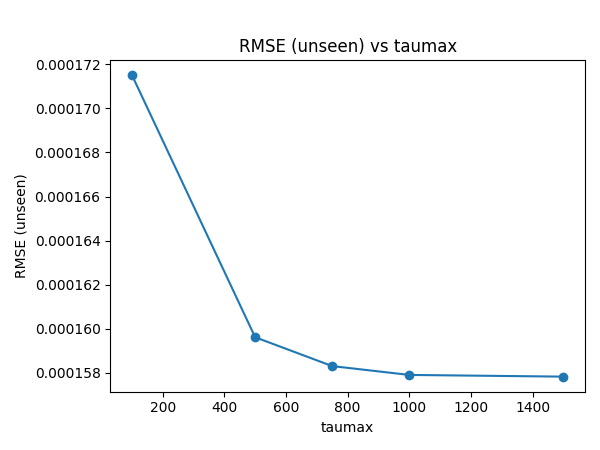

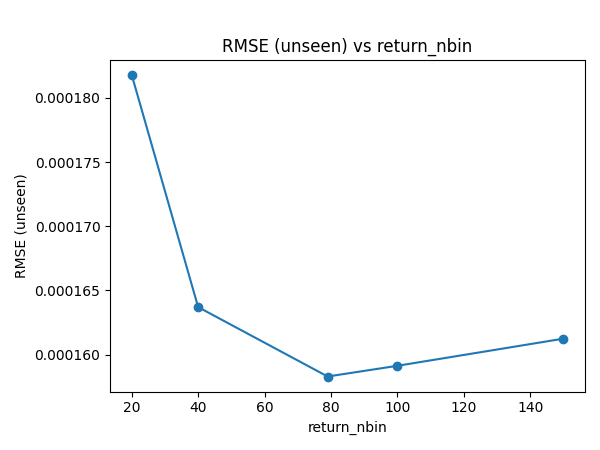

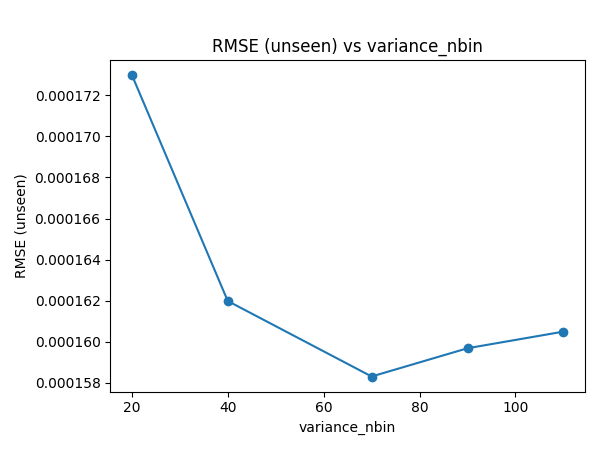

In [ ]:
# Dedicated work .par for the sweeps so we never clobber Parameters.par. param_sweep
# writes the (cloned + overridden) config here, and Utils.multislice_for_sweep forwards
# the same path to Mains.multislice via run_kwargs["paramfile"]. feature_set=return_variance
# is inherited from default_paramfile=PARAMFILE, so return_nbin/variance_nbin are the
# bins that actually take effect.
# Outcome: tick_loss (DeepVaR) at VAR_LEVEL; switch metric= to rmse_unseen / firm_loss / etc.
import importlib
importlib.reload(Utils)

SWEEP_WORK_PAR = "Parameters_FOREX_sweeps.par"
SWEEP_RUN_KWARGS = {
    "paramfile": SWEEP_WORK_PAR,
    "figno": 0,
    "verbose": False,
    "var_level": VAR_LEVEL,
}
SWEEP_METRIC = "tick_loss"

#Define a Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "binmode":       ["rbf", "rbf-quantile"] #"rbf", "rbf-quantile" free choice of rbf or rbf-quantile mode 
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile=PARAMFILE,       # return_variance multislice baseline
    paramfile=SWEEP_WORK_PAR,          # dedicated work file
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric=SWEEP_METRIC,
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath=FIGDIR + "/")

#Define a Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "taumin":        [5,10,20,40,60,80] 
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile=PARAMFILE,       # return_variance multislice baseline
    paramfile=SWEEP_WORK_PAR,          # dedicated work file
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric=SWEEP_METRIC,
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath=FIGDIR + "/")


#Define a Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "taumax":        [100,500,750,1000,1500] 
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile=PARAMFILE,       # return_variance multislice baseline
    paramfile=SWEEP_WORK_PAR,          # dedicated work file
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric=SWEEP_METRIC,
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath=FIGDIR + "/")

#Define a Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "return_nbin":   [20,40,79,100,150] #sweep the decode-target (daily return) bins
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile=PARAMFILE,       # return_variance multislice baseline
    paramfile=SWEEP_WORK_PAR,          # dedicated work file
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric=SWEEP_METRIC,
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath=FIGDIR + "/")

#Define a Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "variance_nbin": [20,40,70,90,110] #sweep the secondary (return variance) bins
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile=PARAMFILE,       # return_variance multislice baseline
    paramfile=SWEEP_WORK_PAR,          # dedicated work file
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric=SWEEP_METRIC,
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath=FIGDIR + "/")



Parameter sweep: 4 combinations to run (metric=tick_loss)
  [1/4] {'variance_window': 7} -> tick_loss = 1.6767e-04  (738.1s, ~36m54s left)
  [2/4] {'variance_window': 14} -> tick_loss = 1.5865e-04  (739.9s, ~24m38s left)
  [3/4] {'variance_window': 21} -> tick_loss = 1.5959e-04  (741.1s, ~12m19s left)
  [4/4] {'variance_window': 28} -> tick_loss = 1.6394e-04  (738.7s, ~0m00s left)
  Saved: figs/FOREX/sweep_variance_window.png


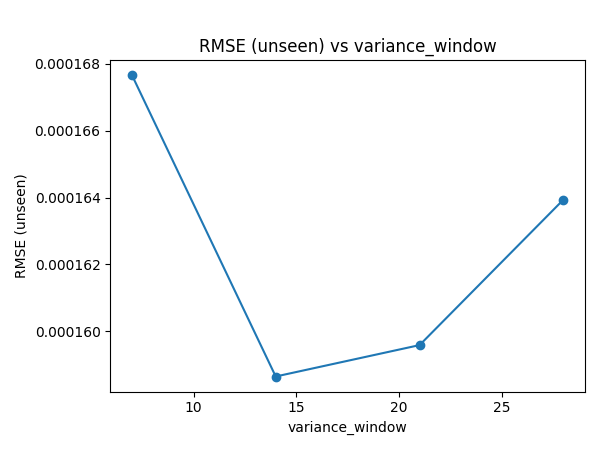

In [19]:
#Define a Sweep — variance_window shifts both secondary-channel smoothing and calendar align
sweep_spec = { # --- Define parameter values to sweep  ---
    "variance_window": [7, 14, 21, 28],  # short → long trailing vol; default 7
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile=PARAMFILE,       # return_variance multislice baseline
    paramfile=SWEEP_WORK_PAR,          # dedicated work file
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric=SWEEP_METRIC,
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath=FIGDIR + "/")

  Saved: figs/FOREX/sweep_K_vs_K_mode.png


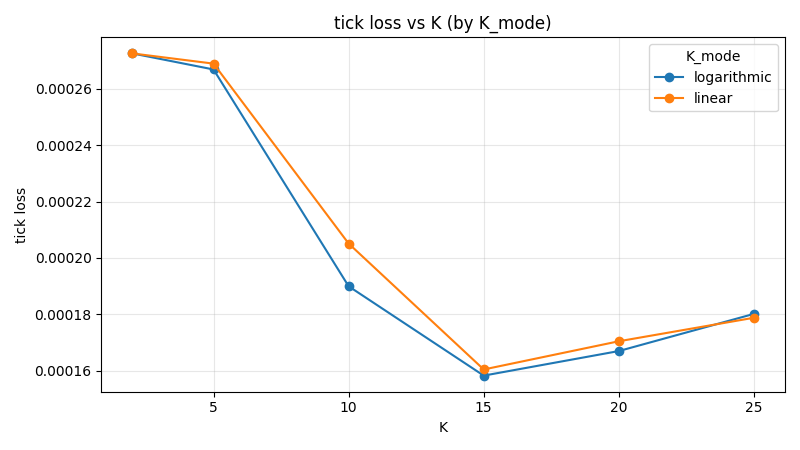

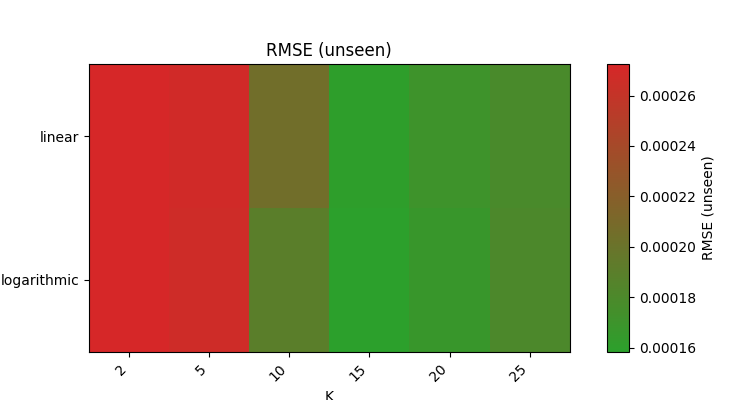

In [ ]:
#Define a Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "K":             [2,5,10,15,20,25], #range from evo search: 2-25
    "K_mode":        ["logarithmic","linear"], #"linear", "logarithmic" free choice of linear or logarithmic mode 
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile=PARAMFILE,       # return_variance multislice baseline
    paramfile=SWEEP_WORK_PAR,          # dedicated work file
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric=SWEEP_METRIC,
)

#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath=FIGDIR + "/")


# K × K_mode 2-D sweep — line plot (alternative to the heatmap in §7)
# Uses `results` and `sweep_spec` from the last sweep block above.
k_vals = sweep_spec["K"]

fig, ax = plt.subplots(figsize=(8, 4.5))
for mode in sweep_spec["K_mode"]:
    ys = [results[(k, mode)] for k in k_vals]
    ax.plot(k_vals, ys, "o-", label=mode)

ax.set_xlabel("K")
ax.set_ylabel("tick loss")
ax.set_title("tick loss vs K (by K_mode)")
ax.legend(title="K_mode")
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 22, "sweep_K_by_K_mode_lines")
plt.show()
